## Generación de Datos Sintéticos para FleetLogix
### Crearemos el código para generar datos sintéticos usando Jupyter Notebook. 
### Objetivo, crear más de 500 registros distribuidos en las 6 tablas de la base de datos.

#### Este primer Bloque es para inicialización del entorno:
 - Importa todas las librerías necesarias 
 - Configura el sistema de logging para monitoreo
 - Establece semillas para reproducibilidad
 - Guarda timestamp de inicio del proyecto (para probar esta funcion)

In [1]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
import logging
import time
from typing import List, Dict, Tuple
import matplotlib.pyplot as plt

# Configuración básica de logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Semillas para reproducibilidad
random.seed(42)
np.random.seed(42)

# Guardar timestamp de inicio
start_time = datetime.now()

print("✅ Librerías importadas y logging configurado")
print(f"🕒 Hora de inicio: {start_time.strftime('%Y-%m-%d %H:%M:%S')}")

✅ Librerías importadas y logging configurado
🕒 Hora de inicio: 2025-09-23 18:29:30


#### Bloque de codigo para definir constantes y configuraciones
- Establece cantidades de registros por tabla
- Define ciudades, tipos de vehículos y mantenimientos
- Configura distribuciones y rangos para datos sintéticos

In [2]:
# Configuración de parámetros del proyecto
NUM_VEHICLES = 200
NUM_DRIVERS = 400
NUM_ROUTES = 50
NUM_TRIPS = 100000
NUM_DELIVERIES = 400000
NUM_MAINTENANCE = 5000

# Ciudades principales (sin tildes)
CITIES = ['Buenos Aires', 'Cordoba', 'Rosario', 'Mendoza', 'La Plata']

# Tipos de vehículos y sus capacidades
VEHICLE_TYPES = {
    'Camion Grande': {'capacity': (8000, 12000), 'fuel_type': 'Diesel'},
    'Camion Mediano': {'capacity': (4000, 8000), 'fuel_type': 'Diesel'},
    'Van': {'capacity': (1000, 2000), 'fuel_type': 'Gasoline'},
    'Motocicleta': {'capacity': (50, 150), 'fuel_type': 'Gasoline'}
}

# Tipos de mantenimiento (sin tildes)
MAINTENANCE_TYPES = [
    'Cambio de aceite',
    'Revision de frenos',
    'Cambio de llantas',
    'Mantenimiento general',
    'Revision de motor',
    'Alineacion y balanceo'
]

logger.info("Parámetros configurados correctamente")
print("✅ Parámetros del proyecto configurados")

2025-09-23 18:29:50,588 - INFO - Parámetros configurados correctamente


✅ Parámetros del proyecto configurados


#### Configuracion de Faker
- Instalar eimporta la librería Faker para datos sintéticos
- Configura Faker en inglés para evitar problemas de caracteres (en primera instancia, lo habia hecho en español, y tuve multiples errores con tildes)
- Establece semilla para datos reproducibles

In [3]:
# Instalar e importar Faker
try:
    from faker import Faker
    logger.info("Faker importado correctamente")
except ImportError:
    !pip install faker
    from faker import Faker
    logger.info("Faker instalado e importado")

# Configurar Faker para inglés (para evitar problemas con tildes y ñ)
fake = Faker('en_US')
Faker.seed(42)

print("✅ Faker configurado en inglés")

2025-09-23 18:30:16,923 - INFO - Faker importado correctamente


✅ Faker configurado en inglés


#### Conectarnos con la base de datos
- Comunicación con PostgreSQL
- Instalar eimporta psycopg2 y SQLAlchemy
- Crear función de conexión a la base de datos
- Verifica que la conexión funcione correctamente

In [4]:
# Instalar e importar librerías de base de datos
try:
    import psycopg2
    from sqlalchemy import create_engine
    logger.info("psycopg2 y SQLAlchemy importados correctamente")
except ImportError:
    !pip install psycopg2-binary sqlalchemy
    import psycopg2
    from sqlalchemy import create_engine
    logger.info("psycopg2 y SQLAlchemy instalados e importados")

# Función de conexión a la base de datos
def create_db_connection():
    """Crea conexión a la base de datos PostgreSQL"""
    try:
        conn = psycopg2.connect(
            host="localhost",
            database="fleetlogix",
            user="fleetlogix_user",
            password="fleetlogix123",
            port="5432"
        )
        logger.info("Conexión a la base de datos establecida exitosamente")
        return conn
    except Exception as e:
        logger.error(f"Error conectando a la base de datos: {e}")
        return None

# Probar la conexión
conn = create_db_connection()
if conn:
    conn.close()
    logger.info("✅ Conexión verificada exitosamente")
else:
    logger.warning("⚠️  Modo local: los datos se generarán pero no se insertarán en BD")

print("✅ Configuración de base de datos completada")

2025-09-23 18:30:38,419 - INFO - psycopg2 y SQLAlchemy importados correctamente
2025-09-23 18:30:38,556 - INFO - Conexión a la base de datos establecida exitosamente
2025-09-23 18:30:38,559 - INFO - ✅ Conexión verificada exitosamente


✅ Configuración de base de datos completada


### Sume este bloque ya que al final, por ingresar los datos como Nat, no corrio las rutas y entregas, solo parcialmente, por lo que no se habia poblado las tablas con la cantidad de datos necesarios
- Limpieza de datos temporales
- Crear función para convertir valores NaT/NaN a None
- Preparar datos para inserción compatible con PostgreSQL
- Manejar tipos de datos datetime correctamente

In [5]:
# Función robusta para convertir NaT a None
def convert_nat_to_none(df: pd.DataFrame) -> pd.DataFrame:
    """Convierte valores NaT/NaN a None para PostgreSQL"""
    df_clean = df.copy()
    
    for col in df_clean.columns:
        if df_clean[col].dtype == 'datetime64[ns]':
            df_clean[col] = df_clean[col].where(df_clean[col].notna(), None)
        elif df_clean[col].dtype in ['float64', 'int64']:
            df_clean[col] = df_clean[col].where(pd.notna(df_clean[col]), None)
    
    return df_clean

print("✅ Función de conversión NaT a None creada")

✅ Función de conversión NaT a None creada


#### Crear datos de la flota vehicular
- Generar 200 vehículos 

In [7]:
# Función para generar datos de vehículos
def generate_vehicles_data(n_vehicles: int) -> pd.DataFrame:
    """Genera datos sintéticos para la tabla vehicles"""
    logger.info(f"Generando {n_vehicles} vehículos...")
    
    vehicles_data = []
    vehicle_types_dist = ['Camion Grande', 'Camion Mediano', 'Van', 'Motocicleta']
    weights = [0.2, 0.3, 0.3, 0.2]  # Distribución de tipos
    
    for i in range(n_vehicles):
        vehicle_type = random.choices(vehicle_types_dist, weights=weights)[0]
        capacity_range = VEHICLE_TYPES[vehicle_type]['capacity']
        
        vehicle = {
            'vehicle_id': i + 1,
            'license_plate': fake.unique.bothify(text='???-###').upper(),
            'vehicle_type': vehicle_type,
            'capacity_kg': round(random.uniform(*capacity_range), 2),
            'fuel_type': VEHICLE_TYPES[vehicle_type]['fuel_type'],
            'acquisition_date': fake.date_between(start_date='-5y', end_date='-6m'),
            'status': random.choices(['active', 'maintenance', 'inactive'], 
                                   weights=[0.8, 0.15, 0.05])[0]
        }
        vehicles_data.append(vehicle)
    
    df = pd.DataFrame(vehicles_data)
    logger.info(f"Vehículos generados: {len(df)} registros")
    return df

# Generar vehículos
vehicles_df = generate_vehicles_data(NUM_VEHICLES)
print("Primeros 5 vehículos:")
print(vehicles_df.head())
print("✅ Datos de vehículos generados")

2025-09-23 18:32:56,436 - INFO - Generando 200 vehículos...
2025-09-23 18:32:56,452 - INFO - Vehículos generados: 200 registros


Primeros 5 vehículos:
   vehicle_id license_plate    vehicle_type  capacity_kg fuel_type  \
0           1       QBI-421   Camion Grande     10880.30    Diesel   
1           2       UBL-539             Van      1690.61  Gasoline   
2           3       HHV-026  Camion Mediano      7171.73    Diesel   
3           4       GLG-775  Camion Mediano      6767.15    Diesel   
4           5       CUY-839             Van      1473.26  Gasoline   

  acquisition_date  status  
0       2020-11-07  active  
1       2022-12-25  active  
2       2021-04-07  active  
3       2024-07-27  active  
4       2025-02-28  active  
✅ Datos de vehículos generados


### Crear datos de conductores
- Generar 400 conductores con información personal realista
- Crear codigos de empleado y numeros de licencia unicos
- Asigna estados laborales 

In [8]:
# Función para generar datos de conductores
def generate_drivers_data(n_drivers: int) -> pd.DataFrame:
    """Genera datos sintéticos para la tabla drivers"""
    logger.info(f"Generando {n_drivers} conductores...")
    
    drivers_data = []
    
    for i in range(n_drivers):
        hire_date = fake.date_between(start_date='-4y', end_date='-3m')
        license_expiry = fake.date_between(start_date=hire_date + timedelta(days=365), 
                                         end_date=hire_date + timedelta(days=1095))
        
        # Generar nombres con límite de caracteres
        first_name = fake.first_name()[:15]
        last_name = fake.last_name()[:15]
        
        driver = {
            'driver_id': i + 1,
            'employee_code': f"EMP{str(i+1).zfill(4)}",
            'first_name': first_name,
            'last_name': last_name,
            'license_number': fake.unique.bothify(text='DL-######').upper(),
            'license_expiry': license_expiry,
            'phone': fake.numerify(text='###-###-####'),
            'hire_date': hire_date,
            'status': random.choices(['active', 'vacation', 'sick_leave', 'inactive'], 
                                   weights=[0.75, 0.1, 0.1, 0.05])[0]
        }
        drivers_data.append(driver)
    
    df = pd.DataFrame(drivers_data)
    logger.info(f"Conductores generados: {len(df)} registros")
    return df

# Generar conductores
drivers_df = generate_drivers_data(NUM_DRIVERS)
print("Primeros 5 conductores:")
print(drivers_df.head())
print("✅ Datos de conductores generados")

2025-09-23 18:33:12,581 - INFO - Generando 400 conductores...
2025-09-23 18:33:12,693 - INFO - Conductores generados: 400 registros


Primeros 5 conductores:
   driver_id employee_code first_name last_name license_number license_expiry  \
0          1       EMP0001    Melanie     Davis      DL-304699     2027-08-09   
1          2       EMP0002      Jason       Lee      DL-173936     2026-08-16   
2          3       EMP0003     Nicole     Owens      DL-753556     2025-05-06   
3          4       EMP0004      James      Hall      DL-937854     2024-04-21   
4          5       EMP0005      Amber       May      DL-080100     2028-07-07   

          phone   hire_date    status  
0  013-983-7354  2025-08-25  vacation  
1  385-467-8544  2025-08-05    active  
2  093-204-8996  2023-04-04    active  
3  777-252-2872  2022-12-25    active  
4  623-120-3875  2025-08-17    active  
✅ Datos de conductores generados


### Definir rutas de transporte
- Genera 50 rutas entre ciudades 
- Calcula distancias, duraciones y costos de peaje realistas
- Crea códigos de ruta unicos para identificación

In [9]:
# Función para generar datos de rutas
def generate_routes_data(n_routes: int) -> pd.DataFrame:
    """Genera datos sintéticos para la tabla routes"""
    logger.info(f"Generando {n_routes} rutas...")
    
    routes_data = []
    
    for i in range(n_routes):
        origin = random.choice(CITIES)
        destination = random.choice([city for city in CITIES if city != origin])
        
        # Distancia basada en ciudades (km)
        base_distance = abs(CITIES.index(origin) - CITIES.index(destination)) * 100 + 50
        distance = round(random.uniform(base_distance, base_distance * 1.5), 2)
        
        # Duración estimada (horas)
        avg_speed = random.uniform(60, 80)  # km/h
        duration = round(distance / avg_speed, 2)
        
        # Costo de peaje
        toll_cost = round(distance * random.uniform(0.05, 0.15), 2)
        
        route = {
            'route_id': i + 1,
            'route_code': f"RT{str(i+1).zfill(3)}",
            'origin_city': origin,
            'destination_city': destination,
            'distance_km': distance,
            'estimated_duration_hours': duration,
            'toll_cost': toll_cost
        }
        routes_data.append(route)
    
    df = pd.DataFrame(routes_data)
    logger.info(f"Rutas generadas: {len(df)} registros")
    return df

# Generar rutas
routes_df = generate_routes_data(NUM_ROUTES)
print("Primeras 5 rutas:")
print(routes_df.head())
print("✅ Datos de rutas generados")

2025-09-23 18:33:29,650 - INFO - Generando 50 rutas...
2025-09-23 18:33:29,653 - INFO - Rutas generadas: 50 registros


Primeras 5 rutas:
   route_id route_code   origin_city destination_city  distance_km  \
0         1      RT001      La Plata          Cordoba       379.96   
1         2      RT002       Rosario     Buenos Aires       353.15   
2         3      RT003      La Plata          Rosario       331.39   
3         4      RT004  Buenos Aires         La Plata       650.02   
4         5      RT005       Rosario         La Plata       280.61   

   estimated_duration_hours  toll_cost  
0                      5.24      53.27  
1                      5.83      19.26  
2                      4.40      30.37  
3                      9.17      74.23  
4                      3.69      25.43  
✅ Datos de rutas generados


### Instertar Datos en Tablas
- Crea función que maneja errores durante inserciones (sume esto, ya que la primera prueba del codigo, tuvo complicaciones)
- Trabaja con lotes pequeños para mejor control
- Convierte tipos de datos y maneja valores nulos

In [10]:
# Función de inserción ultra-robusta
def insert_data_robust(df: pd.DataFrame, table_name: str, conn):
    """Inserta datos en la base de datos PostgreSQL de manera robusta"""
    if conn is None:
        logger.warning(f"No se puede insertar en {table_name} - Sin conexión a BD")
        return False
    
    logger.info(f"Insertando {len(df)} registros en {table_name}...")
    
    try:
        cursor = conn.cursor()
        
        # Convertir DataFrame a lista de tuplas con manejo de tipos
        data_to_insert = []
        for _, row in df.iterrows():
            row_data = []
            for value in row:
                if pd.isna(value):
                    row_data.append(None)
                elif isinstance(value, (pd.Timestamp, np.datetime64)):
                    row_data.append(value.to_pydatetime() if hasattr(value, 'to_pydatetime') else value)
                elif isinstance(value, (np.integer, np.floating)):
                    row_data.append(float(value) if isinstance(value, np.floating) else int(value))
                else:
                    row_data.append(value)
            data_to_insert.append(tuple(row_data))
        
        # Construir consulta INSERT
        columns = ', '.join(df.columns)
        placeholders = ', '.join(['%s'] * len(df.columns))
        insert_query = f"INSERT INTO {table_name} ({columns}) VALUES ({placeholders})"
        
        # Insertar en lotes pequeños
        batch_size = 500
        total_rows = len(data_to_insert)
        successful_inserts = 0
        
        for i in range(0, total_rows, batch_size):
            batch = data_to_insert[i:i + batch_size]
            try:
                cursor.executemany(insert_query, batch)
                successful_inserts += len(batch)
                logger.info(f"Lote {i//batch_size + 1}: {successful_inserts}/{total_rows} registros")
            except Exception as batch_error:
                logger.warning(f"Error en lote {i//batch_size + 1}: {batch_error}")
                # Reintentar fila por fila
                for j, row_data in enumerate(batch):
                    try:
                        cursor.execute(insert_query, row_data)
                        successful_inserts += 1
                    except Exception as row_error:
                        logger.error(f"Error en fila {i + j + 1}: {row_error}")
        
        conn.commit()
        cursor.close()
        
        success = successful_inserts == total_rows
        status = "✅" if success else "⚠️"
        logger.info(f"{status} {table_name}: {successful_inserts}/{total_rows} registros insertados")
        return success
        
    except Exception as e:
        logger.error(f"Error insertando en {table_name}: {e}")
        if 'conn' in locals():
            conn.rollback()
        return False

print("✅ Función de inserción robusta creada")

✅ Función de inserción robusta creada


### Comenzar a poblar tablas maestras en la BD
- Trunca tablas existentes para empezar limpio (ya que se hizo una primera insert que quedo parcial)
- Inserta vehículos, conductores y rutas en la base de datos
- Verifica que la inserción sea exitosa

In [11]:
# Insertar datos maestros en la base de datos
print("🚀 INSERTANDO DATOS MAESTROS EN LA BASE DE DATOS...")

conn = create_db_connection()
if conn:
    try:
        # TRUNCAR todas las tablas para empezar limpio
        cursor = conn.cursor()
        tables = ['deliveries', 'maintenance', 'trips', 'vehicles', 'drivers', 'routes']
        for table in tables:
            try:
                cursor.execute(f"TRUNCATE TABLE {table} RESTART IDENTITY CASCADE")
                logger.info(f"Tabla {table} truncada")
            except Exception as e:
                logger.warning(f"No se pudo truncar {table}: {e}")
        conn.commit()
        cursor.close()
        
        # Insertar vehículos
        vehicles_clean = convert_nat_to_none(vehicles_df)
        if insert_data_robust(vehicles_clean, 'vehicles', conn):
            print("✅ Vehículos insertados correctamente")
        
        # Insertar conductores
        drivers_clean = convert_nat_to_none(drivers_df)
        if insert_data_robust(drivers_clean, 'drivers', conn):
            print("✅ Conductores insertados correctamente")
        
        # Insertar rutas
        routes_clean = convert_nat_to_none(routes_df)
        if insert_data_robust(routes_clean, 'routes', conn):
            print("✅ Rutas insertadas correctamente")
            
    except Exception as e:
        logger.error(f"Error en inserción maestra: {e}")
    finally:
        conn.close()
else:
    print("⚠️  Modo local: Datos generados pero no insertados")

print("✅ Inserción de datos maestros completada")

2025-09-23 18:34:32,076 - INFO - Conexión a la base de datos establecida exitosamente
2025-09-23 18:34:32,108 - INFO - Tabla deliveries truncada
2025-09-23 18:34:32,118 - INFO - Tabla maintenance truncada
2025-09-23 18:34:32,154 - INFO - Tabla trips truncada
2025-09-23 18:34:32,186 - INFO - Tabla vehicles truncada


🚀 INSERTANDO DATOS MAESTROS EN LA BASE DE DATOS...


2025-09-23 18:34:32,220 - INFO - Tabla drivers truncada
2025-09-23 18:34:32,254 - INFO - Tabla routes truncada
2025-09-23 18:34:32,306 - INFO - Insertando 200 registros en vehicles...
2025-09-23 18:34:32,387 - INFO - Lote 1: 200/200 registros
2025-09-23 18:34:32,389 - INFO - ✅ vehicles: 200/200 registros insertados
2025-09-23 18:34:32,393 - INFO - Insertando 400 registros en drivers...
2025-09-23 18:34:32,528 - INFO - Lote 1: 400/400 registros
2025-09-23 18:34:32,530 - INFO - ✅ drivers: 400/400 registros insertados
2025-09-23 18:34:32,535 - INFO - Insertando 50 registros en routes...
2025-09-23 18:34:32,571 - INFO - Lote 1: 50/50 registros
2025-09-23 18:34:32,573 - INFO - ✅ routes: 50/50 registros insertados


✅ Vehículos insertados correctamente
✅ Conductores insertados correctamente
✅ Rutas insertadas correctamente
✅ Inserción de datos maestros completada


#### Para crear los viajes, vamos a modelar patrones de horarios de viaje
- Crear distribución para horas del día segun probabilidad
- Simula patrones reales de transporte 
- Asigna mayores probabilidades a horas pico

In [12]:
# Función auxiliar para distribución horaria
def get_hourly_distribution() -> List[float]:
    """
    Genera una distribución de probabilidad para las horas del día
    basada en patrones típicos de transporte logístico
    """
    distribution = []
    for hour in range(24):
        if 6 <= hour < 9:    # Hora pico mañana: 8%
            prob = 0.08
        elif 9 <= hour < 12: # Mañana: 6%
            prob = 0.06
        elif 12 <= hour < 15: # Medio día: 5%
            prob = 0.05
        elif 15 <= hour < 18: # Tarde: 7%
            prob = 0.07
        elif 18 <= hour < 21: # Hora pico tarde: 9%
            prob = 0.09
        else:                 # Noche/madrugada: 2%
            prob = 0.02
        distribution.append(prob)
    
    # Normalizar para que sume exactamente 1
    total = sum(distribution)
    normalized_dist = [p/total for p in distribution]
    
    return normalized_dist

# Probar la distribución horaria
hourly_dist = get_hourly_distribution()
print("Distribución horaria de viajes:")
for hour, prob in enumerate(hourly_dist):
    print(f"Hora {hour:02d}: {prob:.3%}")

print("✅ Distribución horaria generada")

Distribución horaria de viajes:
Hora 00: 1.626%
Hora 01: 1.626%
Hora 02: 1.626%
Hora 03: 1.626%
Hora 04: 1.626%
Hora 05: 1.626%
Hora 06: 6.504%
Hora 07: 6.504%
Hora 08: 6.504%
Hora 09: 4.878%
Hora 10: 4.878%
Hora 11: 4.878%
Hora 12: 4.065%
Hora 13: 4.065%
Hora 14: 4.065%
Hora 15: 5.691%
Hora 16: 5.691%
Hora 17: 5.691%
Hora 18: 7.317%
Hora 19: 7.317%
Hora 20: 7.317%
Hora 21: 1.626%
Hora 22: 1.626%
Hora 23: 1.626%
✅ Distribución horaria generada


#### Ahora a crear registros de viajes
- Genera 100 mil viajes con datos coherentes
- Asigna vehículos, conductores y rutas aleatorios
- Calcula consumos de combustible y pesos realistas
- Simula diferentes estados de viaje 

In [13]:
# Función principal para generar viajes
def generate_trips_data(n_trips: int, vehicles_df: pd.DataFrame, 
                       drivers_df: pd.DataFrame, routes_df: pd.DataFrame) -> pd.DataFrame:
    """
    Genera datos sintéticos para la tabla trips
    """
    logger.info(f"Generando {n_trips} viajes...")
    
    trips_data = []
    hourly_dist = get_hourly_distribution()
    
    # Filtrar conductores y vehículos activos
    active_drivers = drivers_df[drivers_df['status'] == 'active']['driver_id'].tolist()
    active_vehicles = vehicles_df[vehicles_df['status'] == 'active']['vehicle_id'].tolist()
    
    if not active_drivers or not active_vehicles:
        logger.error("No hay conductores o vehículos activos disponibles")
        return pd.DataFrame()
    
    # Rango de fechas (últimos 2 años)
    end_date = datetime.now()
    start_date = end_date - timedelta(days=730)
    
    for i in range(n_trips):
        # ✅ IMPORTANTE: trip_id comienza desde 1 (tabla vacía)
        trip_id = i + 1
        
        # Seleccionar vehículo, conductor y ruta aleatorios
        vehicle_id = random.choice(active_vehicles)
        driver_id = random.choice(active_drivers)
        route_id = random.choice(routes_df['route_id'].tolist())
        
        # Obtener información de la ruta
        route_info = routes_df[routes_df['route_id'] == route_id].iloc[0]
        estimated_duration = route_info['estimated_duration_hours']
        
        # Generar fecha y hora de salida
        departure_date = fake.date_between(start_date=start_date, end_date=end_date)
        
        # Seleccionar hora basada en distribución
        hour = random.choices(range(24), weights=hourly_dist)[0]
        departure_time = datetime.combine(departure_date, datetime.min.time()) + timedelta(hours=hour)
        
        # Añadir variabilidad a la duración (±20%)
        actual_duration = estimated_duration * random.uniform(0.8, 1.2)
        arrival_time = departure_time + timedelta(hours=actual_duration)
        
        # Calcular consumo de combustible (L/100km * distancia/100)
        fuel_efficiency = random.uniform(25, 40)  # L/100km
        fuel_consumed = round((fuel_efficiency * route_info['distance_km'] / 100), 2)
        
        # Peso total (80-95% de la capacidad del vehículo)
        vehicle_capacity = vehicles_df[vehicles_df['vehicle_id'] == vehicle_id]['capacity_kg'].values[0]
        total_weight = round(vehicle_capacity * random.uniform(0.8, 0.95), 2)
        
        # Estado del viaje
        status = random.choices(['completed', 'in_progress', 'cancelled'], 
                              weights=[0.85, 0.1, 0.05])[0]  # Ajustado para más completados
        
        trip = {
            'trip_id': trip_id,
            'vehicle_id': vehicle_id,
            'driver_id': driver_id,
            'route_id': route_id,
            'departure_datetime': departure_time,
            'arrival_datetime': arrival_time if status == 'completed' else None,
            'fuel_consumed_liters': fuel_consumed if status == 'completed' else None,
            'total_weight_kg': total_weight,
            'status': status
        }
        trips_data.append(trip)
        
        # Log de progreso cada 20,000 registros
        if (i + 1) % 20000 == 0:
            logger.info(f"Generados {i + 1} viajes...")
    
    df = pd.DataFrame(trips_data)
    logger.info(f"Viajes generados: {len(df)} registros")
    return df

# Generar una muestra inicial de 10,000 viajes para prueba
logger.info("Generando muestra inicial de viajes...")
trips_sample = generate_trips_data(10000, vehicles_df, drivers_df, routes_df)

print("Primeros 5 viajes:")
print(trips_sample.head())
print(f"\nDistribución de estados de viajes:")
print(trips_sample['status'].value_counts())
print(f"\nRango de fechas: {trips_sample['departure_datetime'].min()} a {trips_sample['departure_datetime'].max()}")

print("✅ Datos de viajes generados")

2025-09-23 18:36:38,251 - INFO - Generando muestra inicial de viajes...
2025-09-23 18:36:38,254 - INFO - Generando 10000 viajes...
2025-09-23 18:36:48,041 - INFO - Viajes generados: 10000 registros


Primeros 5 viajes:
   trip_id  vehicle_id  driver_id  route_id  departure_datetime  \
0        1          94         26         1 2024-02-07 09:00:00   
1        2         175        366        32 2024-11-05 20:00:00   
2        3         109        109        47 2025-04-11 12:00:00   
3        4         182        133        12 2025-08-04 15:00:00   
4        5         134         66        12 2024-05-19 22:00:00   

            arrival_datetime  fuel_consumed_liters  total_weight_kg     status  
0 2024-02-07 14:27:19.559145                147.91          4264.81  completed  
1 2024-11-06 01:10:23.882409                142.57            93.65  completed  
2 2025-04-11 15:35:36.836482                 80.64          1191.77  completed  
3 2025-08-04 17:44:39.389373                 51.05          4735.75  completed  
4 2024-05-20 00:34:35.588145                 64.11            48.01  completed  

Distribución de estados de viajes:
status
completed      8533
in_progress     977
cancelled

#### Verificamos la consistencia y calidad de datos
- Verificar que las fechas de llegada sean posteriores a salida
- Calcula duraciones reales de viajes
- Detecta inconsistencias en los datos generados

In [14]:
# Verificar consistencia temporal de los viajes
def check_temporal_consistency(trips_df: pd.DataFrame):
    """Verifica la consistencia temporal de los viajes generados"""
    logger.info("Verificando consistencia temporal...")
    
    # Filtrar solo viajes completados
    completed_trips = trips_df[trips_df['status'] == 'completed'].copy()
    
    if completed_trips.empty:
        logger.warning("No hay viajes completados para verificar")
        return
    
    # Calcular duración real
    completed_trips['actual_duration'] = (
        completed_trips['arrival_datetime'] - completed_trips['departure_datetime']
    ).dt.total_seconds() / 3600
    
    # Verificar que arrival > departure
    time_inconsistencies = len(completed_trips[completed_trips['actual_duration'] <= 0])
    
    logger.info(f"Viajes completados: {len(completed_trips)}")
    logger.info(f"Inconsistencias temporales (arrival <= departure): {time_inconsistencies}")
    
    if time_inconsistencies == 0:
        logger.info("✓ Todos los viajes tienen consistencia temporal correcta")
    else:
        logger.warning("Se encontraron inconsistencias temporales")
    
    # Estadísticas de duración
    logger.info(f"Duración promedio: {completed_trips['actual_duration'].mean():.2f} horas")
    logger.info(f"Duración mínima: {completed_trips['actual_duration'].min():.2f} horas")
    logger.info(f"Duración máxima: {completed_trips['actual_duration'].max():.2f} horas")

# Verificar la muestra
check_temporal_consistency(trips_sample)

print("✅ Consistencia temporal verificada")

2025-09-23 18:37:19,434 - INFO - Verificando consistencia temporal...
2025-09-23 18:37:19,452 - INFO - Viajes completados: 8533
2025-09-23 18:37:19,454 - INFO - Inconsistencias temporales (arrival <= departure): 0
2025-09-23 18:37:19,454 - INFO - ✓ Todos los viajes tienen consistencia temporal correcta
2025-09-23 18:37:19,456 - INFO - Duración promedio: 4.34 horas
2025-09-23 18:37:19,458 - INFO - Duración mínima: 1.69 horas
2025-09-23 18:37:19,460 - INFO - Duración máxima: 10.97 horas


✅ Consistencia temporal verificada


#### Realizar Insercion controlada de viajes
- Inserta viajes en lotes de 20 mil para mejor manejo
- Monitorea progreso y maneja errores por lote
- Verifica conteos finales en la base de datos

In [15]:
# Función para insertar viajes en lotes controlados
def insert_trips_in_batches(total_trips: int, batch_size: int = 20000):
    """Inserta viajes en la base de datos en lotes controlados"""
    conn = create_db_connection()
    if not conn:
        logger.error("No se pudo conectar a la base de datos")
        return False
    
    try:
        trips_inserted = 0
        batches = (total_trips + batch_size - 1) // batch_size  # Cálculo de lotes
        
        print(f"🚀 Iniciando inserción de {total_trips} viajes en {batches} lotes de {batch_size}...")
        
        for batch_num in range(batches):
            # Calcular viajes para este lote
            trips_in_batch = min(batch_size, total_trips - trips_inserted)
            start_trip_id = trips_inserted + 1
            
            logger.info(f"Lote {batch_num + 1}/{batches}: Generando {trips_in_batch} viajes...")
            
            # Generar lote de viajes
            trips_batch = generate_trips_data(trips_in_batch, vehicles_df, drivers_df, routes_df)
            
            if trips_batch.empty:
                logger.error(f"Error generando lote {batch_num + 1}")
                continue
            
            # Ajustar trip_ids para este lote
            trips_batch['trip_id'] = range(start_trip_id, start_trip_id + len(trips_batch))
            
            # Limpiar datos y convertir NaT
            trips_clean = convert_nat_to_none(trips_batch)
            
            # Insertar lote
            success = insert_data_robust(trips_clean, 'trips', conn)
            
            if success:
                trips_inserted += len(trips_batch)
                logger.info(f"✅ Lote {batch_num + 1} insertado: {trips_inserted}/{total_trips} viajes")
            else:
                logger.error(f"❌ Error insertando lote {batch_num + 1}")
                # Continuar con siguiente lote en lugar de abortar
        
        logger.info(f"Inserción de viajes completada: {trips_inserted}/{total_trips}")
        return trips_inserted == total_trips
        
    except Exception as e:
        logger.error(f"Error en inserción por lotes: {e}")
        return False
    finally:
        if conn:
            conn.close()

# Insertar viajes en lotes (empezamos con 50,000 para prueba)
print("🎯 INSERTANDO VIAJES EN LA BASE DE DATOS...")
success = insert_trips_in_batches(50000, batch_size=20000)  # 50,000 viajes en lotes de 20,000

if success:
    print("✅ Viajes insertados exitosamente")
else:
    print("⚠️  Algunos viajes no se pudieron insertar")

# Verificar conteo actual en la base de datos
conn = create_db_connection()
if conn:
    cursor = conn.cursor()
    cursor.execute("SELECT COUNT(*) FROM trips")
    current_trips = cursor.fetchone()[0]
    cursor.close()
    conn.close()
    print(f"📊 Viajes en base de datos: {current_trips:,}")
else:
    print("⚠️  No se pudo verificar conteo en BD")

2025-09-23 18:37:30,177 - INFO - Conexión a la base de datos establecida exitosamente
2025-09-23 18:37:30,178 - INFO - Lote 1/3: Generando 20000 viajes...
2025-09-23 18:37:30,178 - INFO - Generando 20000 viajes...


🎯 INSERTANDO VIAJES EN LA BASE DE DATOS...
🚀 Iniciando inserción de 50000 viajes en 3 lotes de 20000...


2025-09-23 18:37:45,504 - INFO - Generados 20000 viajes...
2025-09-23 18:37:45,587 - INFO - Viajes generados: 20000 registros
2025-09-23 18:37:45,611 - INFO - Insertando 20000 registros en trips...
2025-09-23 18:37:46,846 - INFO - Lote 1: 500/20000 registros
2025-09-23 18:37:47,083 - INFO - Lote 2: 1000/20000 registros
2025-09-23 18:37:47,243 - INFO - Lote 3: 1500/20000 registros
2025-09-23 18:37:47,511 - INFO - Lote 4: 2000/20000 registros
2025-09-23 18:37:47,816 - INFO - Lote 5: 2500/20000 registros
2025-09-23 18:37:48,078 - INFO - Lote 6: 3000/20000 registros
2025-09-23 18:37:48,339 - INFO - Lote 7: 3500/20000 registros
2025-09-23 18:37:48,659 - INFO - Lote 8: 4000/20000 registros
2025-09-23 18:37:48,885 - INFO - Lote 9: 4500/20000 registros
2025-09-23 18:37:49,173 - INFO - Lote 10: 5000/20000 registros
2025-09-23 18:37:49,486 - INFO - Lote 11: 5500/20000 registros
2025-09-23 18:37:49,798 - INFO - Lote 12: 6000/20000 registros
2025-09-23 18:37:50,089 - INFO - Lote 13: 6500/20000 reg

✅ Viajes insertados exitosamente
📊 Viajes en base de datos: 50,000


### Crear registros de entregas por viaje
- Genera 400 mil entregas asociadas a viajes completados
- Distribuye entregas a lo largo de la duración del viaje
- Simula diferentes estados de entrega 

In [16]:
# Función para generar datos de entregas
def generate_deliveries_data(n_deliveries: int, trips_df: pd.DataFrame) -> pd.DataFrame:
    """Genera datos sintéticos para la tabla deliveries"""
    logger.info(f"Generando {n_deliveries} entregas...")
    
    deliveries_data = []
    
    # Filtrar solo viajes completados (solo estos tienen entregas)
    completed_trips = trips_df[trips_df['status'] == 'completed'].copy()
    
    if completed_trips.empty:
        logger.error("No hay viajes completados para generar entregas")
        return pd.DataFrame()
    
    logger.info(f"Generando entregas para {len(completed_trips)} viajes completados")
    
    # Calcular entregas por viaje (distribución realista)
    total_completed_trips = len(completed_trips)
    deliveries_per_trip = n_deliveries // total_completed_trips
    remainder = n_deliveries % total_completed_trips
    
    delivery_id_counter = 1
    
    for trip_idx, trip in completed_trips.iterrows():
        # Número de entregas para este viaje
        if trip_idx < remainder:
            n_deliveries_this_trip = deliveries_per_trip + 1
        else:
            n_deliveries_this_trip = deliveries_per_trip
        
        # Información del viaje
        trip_id = trip['trip_id']
        departure_time = trip['departure_datetime']
        arrival_time = trip['arrival_datetime']
        
        # Duración del viaje en horas
        trip_duration_hours = (arrival_time - departure_time).total_seconds() / 3600
        
        for delivery_num in range(n_deliveries_this_trip):
            if delivery_id_counter > n_deliveries:
                break
                
            # Distribuir las entregas a lo largo del viaje
            delivery_progress = (delivery_num + 1) / (n_deliveries_this_trip + 1)
            delivery_time = departure_time + timedelta(hours=trip_duration_hours * delivery_progress)
            
            # Estado de la entrega (primera entrega más probable de completar)
            if delivery_num == 0:
                status_weights = [0.95, 0.04, 0.01]  # completed, pending, failed
            elif delivery_num == n_deliveries_this_trip - 1:  # última entrega
                status_weights = [0.80, 0.15, 0.05]
            else:
                status_weights = [0.90, 0.07, 0.03]
            
            delivery_status = random.choices(['completed', 'pending', 'failed'], 
                                           weights=status_weights)[0]
            
            delivery = {
                'delivery_id': delivery_id_counter,
                'trip_id': trip_id,
                'tracking_number': f"TRK{str(delivery_id_counter).zfill(8)}",
                'customer_name': fake.name(),
                'delivery_address': fake.address().replace('\n', ', ')[:100],  # Limitar longitud
                'package_weight_kg': round(random.uniform(5, 200), 2),
                'scheduled_datetime': delivery_time,
                'delivered_datetime': delivery_time if delivery_status == 'completed' else None,
                'delivery_status': delivery_status,
                'recipient_signature': delivery_status == 'completed' and random.random() > 0.3
            }
            deliveries_data.append(delivery)
            delivery_id_counter += 1
            
            # Log de progreso
            if delivery_id_counter % 50000 == 0:
                logger.info(f"Generadas {delivery_id_counter} entregas...")
                
            if delivery_id_counter > n_deliveries:
                break
    
    df = pd.DataFrame(deliveries_data)
    logger.info(f"Entregas generadas: {len(df)} registros")
    logger.info(f"Promedio de entregas por viaje: {len(df) / len(completed_trips):.2f}")
    return df

# Generar una muestra de entregas para prueba (20,000 entregas)
logger.info("Generando muestra inicial de entregas...")
deliveries_sample = generate_deliveries_data(20000, trips_sample)

print("Primeras 5 entregas:")
print(deliveries_sample.head())
print(f"\nDistribución de estados de entregas:")
print(deliveries_sample['delivery_status'].value_counts())
print(f"\nPromedio de entregas por viaje: {len(deliveries_sample) / len(trips_sample[trips_sample['status'] == 'completed']):.2f}")

print("✅ Datos de entregas generados")

2025-09-23 18:39:53,389 - INFO - Generando muestra inicial de entregas...
2025-09-23 18:39:53,392 - INFO - Generando 20000 entregas...
2025-09-23 18:39:53,399 - INFO - Generando entregas para 8533 viajes completados
2025-09-23 18:40:05,507 - INFO - Entregas generadas: 19596 registros
2025-09-23 18:40:05,508 - INFO - Promedio de entregas por viaje: 2.30


Primeras 5 entregas:
   delivery_id  trip_id tracking_number    customer_name  \
0            1        1     TRK00000001   Vickie Shaffer   
1            2        1     TRK00000002  Mrs. Diana King   
2            3        1     TRK00000003    Adam Fletcher   
3            4        2     TRK00000004     Laura Dillon   
4            5        2     TRK00000005   Charles Harris   

                                    delivery_address  package_weight_kg  \
0        5083 Allen Mountain, Phyllismouth, FL 89817             138.94   
1                579 Nguyen Mews, New Adam, ID 29689             124.18   
2  8048 Christie Highway Apt. 782, Lopezstad, NC ...              25.77   
3        2587 Oscar Pine, West Michaelberg, GU 89163             119.39   
4        7501 Mitchell Vista, Lake Shelley, WA 03706             188.22   

          scheduled_datetime         delivered_datetime delivery_status  \
0 2024-02-07 10:21:49.889786 2024-02-07 10:21:49.889786       completed   
1 2024-02-07 11:4

### Conectar entregas con viajes reales, obtenidos de BD
- Consultar la base de datos para obtener viajes existentes
- Garantizar que las entregas referencien viajes válidos
- Preparar datos para generación coherente de entregas

In [17]:
# Función para obtener viajes desde la base de datos
def get_trips_from_db(limit: int = None):
    """Obtiene viajes desde la base de datos para generar entregas reales"""
    conn = create_db_connection()
    if not conn:
        logger.error("No se pudo conectar a la base de datos")
        return pd.DataFrame()
    
    try:
        query = """
        SELECT trip_id, vehicle_id, driver_id, route_id, 
               departure_datetime, arrival_datetime, 
               fuel_consumed_liters, total_weight_kg, status
        FROM trips 
        WHERE status = 'completed'
        """
        if limit:
            query += f" LIMIT {limit}"
        
        trips_df = pd.read_sql(query, conn)
        logger.info(f"Obtenidos {len(trips_df)} viajes completados desde BD")
        return trips_df
        
    except Exception as e:
        logger.error(f"Error obteniendo viajes desde BD: {e}")
        return pd.DataFrame()
    finally:
        if conn:
            conn.close()

# Obtener viajes reales desde la base de datos
print("📥 OBTENIENDO VIAJES REALES DESDE LA BASE DE DATOS...")
real_trips_df = get_trips_from_db(limit=50000)  # Obtener todos los viajes completados

if not real_trips_df.empty:
    print(f"✅ Obtenidos {len(real_trips_df)} viajes completados desde BD")
    print(f"Rango de trip_id: {real_trips_df['trip_id'].min()} a {real_trips_df['trip_id'].max()}")
else:
    print("❌ No se pudieron obtener viajes desde BD")
    # Usar los viajes generados localmente como fallback
    real_trips_df = trips_sample[trips_sample['status'] == 'completed']
    print(f"⚠️  Usando {len(real_trips_df)} viajes locales como fallback")

2025-09-23 18:40:31,081 - INFO - Conexión a la base de datos establecida exitosamente


📥 OBTENIENDO VIAJES REALES DESDE LA BASE DE DATOS...


C:\Users\yaela\AppData\Local\Temp\ipykernel_12596\3716220000.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  trips_df = pd.read_sql(query, conn)
2025-09-23 18:40:31,432 - INFO - Obtenidos 42541 viajes completados desde BD


✅ Obtenidos 42541 viajes completados desde BD
Rango de trip_id: 1 a 50000


#### Nuevamente vamos a ingresar en lotes, y conectar entregas con viajes reales de BD
- Insertar entregas en lotes de 50 mil
- Generar numeros de tracking unicos para cada entrega
- Verificar integridad referencial con viajes

In [18]:
# Función para insertar entregas en lotes
def insert_deliveries_in_batches(total_deliveries: int, batch_size: int = 50000):
    """Inserta entregas en la base de datos en lotes controlados"""
    conn = create_db_connection()
    if not conn:
        logger.error("No se pudo conectar a la base de datos")
        return False
    
    try:
        # Obtener viajes completados desde BD
        completed_trips_df = get_trips_from_db()
        if completed_trips_df.empty:
            logger.error("No hay viajes completados en la BD para generar entregas")
            return False
        
        deliveries_inserted = 0
        batches = (total_deliveries + batch_size - 1) // batch_size
        
        print(f"🚀 Iniciando inserción de {total_deliveries} entregas en {batches} lotes...")
        
        for batch_num in range(batches):
            # Calcular entregas para este lote
            deliveries_in_batch = min(batch_size, total_deliveries - deliveries_inserted)
            
            logger.info(f"Lote {batch_num + 1}/{batches}: Generando {deliveries_in_batch} entregas...")
            
            # Generar lote de entregas
            deliveries_batch = generate_deliveries_data(deliveries_in_batch, completed_trips_df)
            
            if deliveries_batch.empty:
                logger.error(f"Error generando lote {batch_num + 1} de entregas")
                continue
            
            # Ajustar delivery_ids para este lote
            start_delivery_id = deliveries_inserted + 1
            deliveries_batch['delivery_id'] = range(start_delivery_id, start_delivery_id + len(deliveries_batch))
            
            # Actualizar tracking numbers
            for idx, row in deliveries_batch.iterrows():
                deliveries_batch.at[idx, 'tracking_number'] = f"TRK{str(row['delivery_id']).zfill(8)}"
            
            # Limpiar datos y convertir NaT
            deliveries_clean = convert_nat_to_none(deliveries_batch)
            
            # Insertar lote
            success = insert_data_robust(deliveries_clean, 'deliveries', conn)
            
            if success:
                deliveries_inserted += len(deliveries_batch)
                logger.info(f"✅ Lote {batch_num + 1} insertado: {deliveries_inserted}/{total_deliveries} entregas")
            else:
                logger.error(f"❌ Error insertando lote {batch_num + 1} de entregas")
        
        logger.info(f"Inserción de entregas completada: {deliveries_inserted}/{total_deliveries}")
        return deliveries_inserted == total_deliveries
        
    except Exception as e:
        logger.error(f"Error en inserción de entregas: {e}")
        return False
    finally:
        if conn:
            conn.close()

# Insertar entregas en lotes (empezamos con 100,000 para prueba)
print("🎯 INSERTANDO ENTREGAS EN LA BASE DE DATOS...")
success = insert_deliveries_in_batches(100000, batch_size=50000)  # 100,000 entregas en lotes de 50,000

if success:
    print("✅ Entregas insertadas exitosamente")
else:
    print("⚠️  Algunas entregas no se pudieron insertar")

# Verificar conteo actual en la base de datos
conn = create_db_connection()
if conn:
    cursor = conn.cursor()
    cursor.execute("SELECT COUNT(*) FROM deliveries")
    current_deliveries = cursor.fetchone()[0]
    cursor.close()
    conn.close()
    print(f"📊 Entregas en base de datos: {current_deliveries:,}")
    
    # Calcular porcentaje completado
    completion_pct = (current_deliveries / NUM_DELIVERIES) * 100
    print(f"📈 Porcentaje completado: {completion_pct:.1f}%")
else:
    print("⚠️  No se pudo verificar conteo en BD")

2025-09-23 18:41:58,006 - INFO - Conexión a la base de datos establecida exitosamente
2025-09-23 18:41:58,108 - INFO - Conexión a la base de datos establecida exitosamente


🎯 INSERTANDO ENTREGAS EN LA BASE DE DATOS...


C:\Users\yaela\AppData\Local\Temp\ipykernel_12596\3716220000.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  trips_df = pd.read_sql(query, conn)
2025-09-23 18:41:58,703 - INFO - Obtenidos 42541 viajes completados desde BD
2025-09-23 18:41:58,705 - INFO - Lote 1/2: Generando 50000 entregas...
2025-09-23 18:41:58,706 - INFO - Generando 50000 entregas...
2025-09-23 18:41:58,719 - INFO - Generando entregas para 42541 viajes completados


🚀 Iniciando inserción de 100000 entregas en 2 lotes...


2025-09-23 18:42:27,367 - INFO - Generadas 50000 entregas...
2025-09-23 18:42:27,575 - INFO - Entregas generadas: 50000 registros
2025-09-23 18:42:27,577 - INFO - Promedio de entregas por viaje: 1.18
2025-09-23 18:42:30,419 - INFO - Insertando 50000 registros en deliveries...
2025-09-23 18:42:33,127 - INFO - Lote 1: 500/50000 registros
2025-09-23 18:42:33,355 - INFO - Lote 2: 1000/50000 registros
2025-09-23 18:42:33,564 - INFO - Lote 3: 1500/50000 registros
2025-09-23 18:42:33,778 - INFO - Lote 4: 2000/50000 registros
2025-09-23 18:42:34,038 - INFO - Lote 5: 2500/50000 registros
2025-09-23 18:42:34,336 - INFO - Lote 6: 3000/50000 registros
2025-09-23 18:42:34,638 - INFO - Lote 7: 3500/50000 registros
2025-09-23 18:42:34,900 - INFO - Lote 8: 4000/50000 registros
2025-09-23 18:42:35,171 - INFO - Lote 9: 4500/50000 registros
2025-09-23 18:42:35,405 - INFO - Lote 10: 5000/50000 registros
2025-09-23 18:42:35,595 - INFO - Lote 11: 5500/50000 registros
2025-09-23 18:42:35,833 - INFO - Lote 12

✅ Entregas insertadas exitosamente
📊 Entregas en base de datos: 100,000
📈 Porcentaje completado: 25.0%


#### Crear registros de mantenimiento vehicular
- Generar 5 mil registros de mantenimiento
- Asociar mantenimientos a vehículos existentes
- Simular diferentes tipos de servicio y costos

In [19]:
# Función para generar datos de mantenimiento
def generate_maintenance_data(n_maintenance: int, vehicles_df: pd.DataFrame) -> pd.DataFrame:
    """Genera datos sintéticos para la tabla maintenance"""
    logger.info(f"Generando {n_maintenance} registros de mantenimiento...")
    
    maintenance_data = []
    
    # Obtener vehículos activos
    active_vehicles = vehicles_df[vehicles_df['status'].isin(['active', 'maintenance'])]['vehicle_id'].tolist()
    
    if not active_vehicles:
        logger.error("No hay vehículos activos disponibles")
        return pd.DataFrame()
    
    for i in range(n_maintenance):
        # Seleccionar vehículo aleatorio
        vehicle_id = random.choice(active_vehicles)
        
        # Obtener fecha de adquisición del vehículo
        acquisition_date = vehicles_df[vehicles_df['vehicle_id'] == vehicle_id]['acquisition_date'].values[0]
        
        # Fecha de mantenimiento (después de la adquisición)
        maintenance_date = fake.date_between(start_date=acquisition_date, end_date='today')
        
        # Tipo de mantenimiento
        maintenance_type = random.choice(MAINTENANCE_TYPES)
        
        # Costo basado en el tipo de mantenimiento
        cost_ranges = {
            'Cambio de aceite': (500, 1500),
            'Revision de frenos': (800, 2000),
            'Cambio de llantas': (2000, 5000),
            'Mantenimiento general': (1500, 4000),
            'Revision de motor': (1000, 3000),
            'Alineacion y balanceo': (600, 1800)
        }
        cost = round(random.uniform(*cost_ranges[maintenance_type]), 2)
        
        # Próximo mantenimiento (1-6 meses después)
        next_maintenance = maintenance_date + timedelta(days=random.randint(30, 180))
        
        maintenance = {
            'maintenance_id': i + 1,
            'vehicle_id': vehicle_id,
            'maintenance_date': maintenance_date,
            'maintenance_type': maintenance_type,
            'description': f"{maintenance_type} realizado por {fake.company()}",
            'cost': cost,
            'next_maintenance_date': next_maintenance,
            'performed_by': fake.company()
        }
        maintenance_data.append(maintenance)
        
        # Log de progreso
        if (i + 1) % 1000 == 0:
            logger.info(f"Generados {i + 1} mantenimientos...")
    
    df = pd.DataFrame(maintenance_data)
    logger.info(f"Mantenimientos generados: {len(df)} registros")
    
    # Estadísticas
    maintenance_per_vehicle = len(df) / len(active_vehicles)
    logger.info(f"Promedio de mantenimientos por vehículo: {maintenance_per_vehicle:.2f}")
    
    return df

# Generar datos de mantenimiento
logger.info("Generando datos de mantenimiento...")
maintenance_df = generate_maintenance_data(NUM_MAINTENANCE, vehicles_df)

print("Primeros 5 registros de mantenimiento:")
print(maintenance_df.head())
print(f"\nDistribución de tipos de mantenimiento:")
print(maintenance_df['maintenance_type'].value_counts())

print("✅ Datos de mantenimiento generados")

2025-09-23 18:44:56,786 - INFO - Generando datos de mantenimiento...
2025-09-23 18:44:56,788 - INFO - Generando 5000 registros de mantenimiento...
2025-09-23 18:44:57,846 - INFO - Generados 1000 mantenimientos...
2025-09-23 18:44:59,046 - INFO - Generados 2000 mantenimientos...
2025-09-23 18:44:59,981 - INFO - Generados 3000 mantenimientos...
2025-09-23 18:45:01,067 - INFO - Generados 4000 mantenimientos...
2025-09-23 18:45:02,294 - INFO - Generados 5000 mantenimientos...
2025-09-23 18:45:02,313 - INFO - Mantenimientos generados: 5000 registros
2025-09-23 18:45:02,317 - INFO - Promedio de mantenimientos por vehículo: 26.32


Primeros 5 registros de mantenimiento:
   maintenance_id  vehicle_id maintenance_date       maintenance_type  \
0               1          91       2025-04-18      Revision de motor   
1               2          61       2025-09-18      Cambio de llantas   
2               3         156       2025-08-12      Revision de motor   
3               4         160       2025-05-26  Alineacion y balanceo   
4               5         197       2025-03-10      Cambio de llantas   

                                         description     cost  \
0  Revision de motor realizado por Davis, Payne a...  1065.53   
1          Cambio de llantas realizado por Hayes Ltd  2057.01   
2        Revision de motor realizado por May-Jimenez  1987.63   
3      Alineacion y balanceo realizado por Stone LLC  1701.30   
4  Cambio de llantas realizado por Rodriguez, Jon...  2753.28   

  next_maintenance_date                 performed_by  
0            2025-08-20  Patrick, Williams and Evans  
1            2025-10-

#### Subir los datos a la tabla de mantenimiento en lotes
- Inserta registros de mantenimiento en la BD
- Verifica que la insercion sea exitosa
- Confirma conteos finales

In [20]:
# Insertar datos de mantenimiento
print("🔧 INSERTANDO DATOS DE MANTENIMIENTO...")

conn = create_db_connection()
if conn:
    try:
        # Limpiar y convertir datos
        maintenance_clean = convert_nat_to_none(maintenance_df)
        
        # Insertar mantenimiento
        success = insert_data_robust(maintenance_clean, 'maintenance', conn)
        
        if success:
            print("✅ Mantenimiento insertado exitosamente")
        else:
            print("⚠️  Error insertando mantenimiento")
            
    except Exception as e:
        logger.error(f"Error insertando mantenimiento: {e}")
    finally:
        conn.close()

# Verificar conteo
conn = create_db_connection()
if conn:
    cursor = conn.cursor()
    cursor.execute("SELECT COUNT(*) FROM maintenance")
    current_maintenance = cursor.fetchone()[0]
    cursor.close()
    conn.close()
    print(f"📊 Mantenimientos en base de datos: {current_maintenance:,}")
else:
    print("⚠️  No se pudo verificar conteo de mantenimiento")

2025-09-23 18:45:23,588 - INFO - Conexión a la base de datos establecida exitosamente
2025-09-23 18:45:23,593 - INFO - Insertando 5000 registros en maintenance...


🔧 INSERTANDO DATOS DE MANTENIMIENTO...


2025-09-23 18:45:23,940 - INFO - Lote 1: 500/5000 registros
2025-09-23 18:45:24,124 - INFO - Lote 2: 1000/5000 registros
2025-09-23 18:45:24,283 - INFO - Lote 3: 1500/5000 registros
2025-09-23 18:45:24,464 - INFO - Lote 4: 2000/5000 registros
2025-09-23 18:45:24,649 - INFO - Lote 5: 2500/5000 registros
2025-09-23 18:45:24,818 - INFO - Lote 6: 3000/5000 registros
2025-09-23 18:45:24,974 - INFO - Lote 7: 3500/5000 registros
2025-09-23 18:45:25,132 - INFO - Lote 8: 4000/5000 registros
2025-09-23 18:45:25,249 - INFO - Lote 9: 4500/5000 registros
2025-09-23 18:45:25,383 - INFO - Lote 10: 5000/5000 registros
2025-09-23 18:45:25,391 - INFO - ✅ maintenance: 5000/5000 registros insertados
2025-09-23 18:45:25,454 - INFO - Conexión a la base de datos establecida exitosamente


✅ Mantenimiento insertado exitosamente
📊 Mantenimientos en base de datos: 5,000


### Vamos a revisar y completar datos faltantes si los hay
- Detectar y calcular registros faltantes por tabla
- Generar e insertar solo los datos necesarios
- Verificar que se alcancen las cantidades objetivo

In [ ]:
# Función para completar todos los registros faltantes
def complete_all_missing_records():
    """Completa todos los registros faltantes de manera controlada"""
    print("🎯 COMPLETANDO REGISTROS FALTANTES...")
    print("=" * 50)
    
    conn = create_db_connection()
    if not conn:
        print("❌ No se pudo conectar a la base de datos")
        return
    
    try:
        # Obtener conteos actuales
        cursor = conn.cursor()
        
        # Viajes
        cursor.execute("SELECT COUNT(*) FROM trips")
        current_trips = cursor.fetchone()[0]
        missing_trips = NUM_TRIPS - current_trips
        
        # Entregas
        cursor.execute("SELECT COUNT(*) FROM deliveries")
        current_deliveries = cursor.fetchone()[0]
        missing_deliveries = NUM_DELIVERIES - current_deliveries
        
        # Mantenimiento
        cursor.execute("SELECT COUNT(*) FROM maintenance")
        current_maintenance = cursor.fetchone()[0]
        missing_maintenance = NUM_MAINTENANCE - current_maintenance
        
        print(f"📊 ESTADO ACTUAL:")
        print(f"   • Viajes: {current_trips:,} / {NUM_TRIPS:,} (Faltan: {missing_trips:,})")
        print(f"   • Entregas: {current_deliveries:,} / {NUM_DELIVERIES:,} (Faltan: {missing_deliveries:,})")
        print(f"   • Mantenimiento: {current_maintenance:,} / {NUM_MAINTENANCE:,} (Faltan: {missing_maintenance:,})")
        
        # COMPLETAR VIAJES FALTANTES
        if missing_trips > 0:
            print(f"\n COMPLETANDO {missing_trips:,} VIAJES FALTANTES...")
            
            # Obtener el último trip_id
            cursor.execute("SELECT COALESCE(MAX(trip_id), 0) FROM trips")
            last_trip_id = cursor.fetchone()[0]
            
            # Generar viajes faltantes
            trips_to_generate = generate_trips_data(missing_trips, vehicles_df, drivers_df, routes_df)
            
            if not trips_to_generate.empty:
                # Reasignar IDs correctamente
                trips_to_generate['trip_id'] = range(last_trip_id + 1, last_trip_id + 1 + len(trips_to_generate))
                
                # Insertar
                trips_clean = convert_nat_to_none(trips_to_generate)
                success = insert_data_robust(trips_clean, 'trips', conn)
                
                if success:
                    print(f"✅ {missing_trips:,} viajes faltantes insertados")
                    current_trips += missing_trips
                else:
                    print("❌ Error insertando viajes faltantes")
        
        # COMPLETAR ENTREGAS FALTANTES
        if missing_deliveries > 0:
            print(f"\n📦 COMPLETANDO {missing_deliveries:,} ENTREGAS FALTANTES...")
            
            # Obtener viajes completados actualizados
            completed_trips_df = get_trips_from_db()
            
            if not completed_trips_df.empty:
                # Obtener último delivery_id
                cursor.execute("SELECT COALESCE(MAX(delivery_id), 0) FROM deliveries")
                last_delivery_id = cursor.fetchone()[0]
                
                # Generar entregas faltantes
                deliveries_to_generate = generate_deliveries_data(missing_deliveries, completed_trips_df)
                
                if not deliveries_to_generate.empty:
                    # Reasignar IDs
                    deliveries_to_generate['delivery_id'] = range(last_delivery_id + 1, last_delivery_id + 1 + len(deliveries_to_generate))
                    
                    # Actualizar tracking numbers
                    for idx, row in deliveries_to_generate.iterrows():
                        deliveries_to_generate.at[idx, 'tracking_number'] = f"TRK{str(row['delivery_id']).zfill(8)}"
                    
                    # Insertar
                    deliveries_clean = convert_nat_to_none(deliveries_to_generate)
                    success = insert_data_robust(deliveries_clean, 'deliveries', conn)
                    
                    if success:
                        print(f"✅ {missing_deliveries:,} entregas faltantes insertadas")
                    else:
                        print("❌ Error insertando entregas faltantes")
        
        # COMPLETAR MANTENIMIENTO FALTANTE
        if missing_maintenance > 0:
            print(f"\n🔧 COMPLETANDO {missing_maintenance:,} MANTENIMIENTOS FALTANTES...")
            
            # Obtener último maintenance_id
            cursor.execute("SELECT COALESCE(MAX(maintenance_id), 0) FROM maintenance")
            last_maintenance_id = cursor.fetchone()[0]
            
            # Generar mantenimiento faltante
            maintenance_to_generate = generate_maintenance_data(missing_maintenance, vehicles_df)
            
            if not maintenance_to_generate.empty:
                # Reasignar IDs
                maintenance_to_generate['maintenance_id'] = range(last_maintenance_id + 1, last_maintenance_id + 1 + len(maintenance_to_generate))
                
                # Insertar
                maintenance_clean = convert_nat_to_none(maintenance_to_generate)
                success = insert_data_robust(maintenance_clean, 'maintenance', conn)
                
                if success:
                    print(f"✅ {missing_maintenance:,} mantenimientos faltantes insertados")
                else:
                    print("❌ Error insertando mantenimientos faltantes")
        
        # VERIFICACIÓN FINAL
        print(f"\n📋 VERIFICACIÓN FINAL:")
        cursor.execute("SELECT COUNT(*) FROM trips")
        final_trips = cursor.fetchone()[0]
        cursor.execute("SELECT COUNT(*) FROM deliveries")
        final_deliveries = cursor.fetchone()[0]
        cursor.execute("SELECT COUNT(*) FROM maintenance")
        final_maintenance = cursor.fetchone()[0]
        
        print(f"   • Viajes: {final_trips:,} / {NUM_TRIPS:,} ({(final_trips/NUM_TRIPS*100):.1f}%)")
        print(f"   • Entregas: {final_deliveries:,} / {NUM_DELIVERIES:,} ({(final_deliveries/NUM_DELIVERIES*100):.1f}%)")
        print(f"   • Mantenimiento: {final_maintenance:,} / {NUM_MAINTENANCE:,} ({(final_maintenance/NUM_MAINTENANCE*100):.1f}%)")
        
        if final_trips == NUM_TRIPS and final_deliveries == NUM_DELIVERIES and final_maintenance == NUM_MAINTENANCE:
            print("\n ¡TODOS LOS REGISTROS COMPLETADOS EXITOSAMENTE!")
        else:
            print("\n  Algunos registros aún faltan")
        
    except Exception as e:
        print(f"❌ Error completando registros: {e}")
    finally:
        if conn:
            conn.close()

# Ejecutar completado de registros
complete_all_missing_records()

2025-09-23 18:46:21,918 - INFO - Conexión a la base de datos establecida exitosamente
2025-09-23 18:46:21,950 - INFO - Generando 50000 viajes...


🎯 COMPLETANDO REGISTROS FALTANTES...
📊 ESTADO ACTUAL:
   • Viajes: 50,000 / 100,000 (Faltan: 50,000)
   • Entregas: 100,000 / 400,000 (Faltan: 300,000)
   • Mantenimiento: 5,000 / 5,000 (Faltan: 0)

🚗 COMPLETANDO 50,000 VIAJES FALTANTES...


2025-09-23 18:46:37,141 - INFO - Generados 20000 viajes...
2025-09-23 18:46:51,360 - INFO - Generados 40000 viajes...
2025-09-23 18:46:59,111 - INFO - Viajes generados: 50000 registros
2025-09-23 18:46:59,149 - INFO - Insertando 50000 registros en trips...
2025-09-23 18:47:01,722 - INFO - Lote 1: 500/50000 registros
2025-09-23 18:47:01,986 - INFO - Lote 2: 1000/50000 registros
2025-09-23 18:47:02,186 - INFO - Lote 3: 1500/50000 registros
2025-09-23 18:47:02,501 - INFO - Lote 4: 2000/50000 registros
2025-09-23 18:47:02,775 - INFO - Lote 5: 2500/50000 registros
2025-09-23 18:47:03,038 - INFO - Lote 6: 3000/50000 registros
2025-09-23 18:47:03,303 - INFO - Lote 7: 3500/50000 registros
2025-09-23 18:47:03,620 - INFO - Lote 8: 4000/50000 registros
2025-09-23 18:47:03,897 - INFO - Lote 9: 4500/50000 registros
2025-09-23 18:47:04,187 - INFO - Lote 10: 5000/50000 registros
2025-09-23 18:47:04,507 - INFO - Lote 11: 5500/50000 registros
2025-09-23 18:47:04,756 - INFO - Lote 12: 6000/50000 registr

✅ 50,000 viajes faltantes insertados

📦 COMPLETANDO 300,000 ENTREGAS FALTANTES...


2025-09-23 18:47:33,716 - INFO - Obtenidos 84975 viajes completados desde BD
2025-09-23 18:47:33,719 - INFO - Generando 300000 entregas...
2025-09-23 18:47:33,751 - INFO - Generando entregas para 84975 viajes completados
2025-09-23 18:48:00,589 - INFO - Generadas 50000 entregas...
2025-09-23 18:48:29,762 - INFO - Generadas 100000 entregas...
2025-09-23 18:48:51,690 - INFO - Generadas 150000 entregas...
2025-09-23 18:49:15,311 - INFO - Generadas 200000 entregas...
2025-09-23 18:49:36,918 - INFO - Generadas 250000 entregas...
2025-09-23 18:49:57,794 - INFO - Generadas 300000 entregas...
2025-09-23 18:49:59,016 - INFO - Entregas generadas: 300000 registros
2025-09-23 18:49:59,018 - INFO - Promedio de entregas por viaje: 3.53
2025-09-23 18:50:16,730 - INFO - Insertando 300000 registros en deliveries...
2025-09-23 18:50:32,705 - INFO - Lote 1: 500/300000 registros
2025-09-23 18:50:32,958 - INFO - Lote 2: 1000/300000 registros
2025-09-23 18:50:33,195 - INFO - Lote 3: 1500/300000 registros
20

✅ 300,000 entregas faltantes insertadas

📋 VERIFICACIÓN FINAL:
   • Viajes: 100,000 / 100,000 (100.0%)
   • Entregas: 400,000 / 400,000 (100.0%)
   • Mantenimiento: 5,000 / 5,000 (100.0%)

🎉 ¡TODOS LOS REGISTROS COMPLETADOS EXITOSAMENTE!


#### Ahora con registros completados, vamos a revisar estadisticas Finales
- Calcular métricas de calidad y que tan completa quedo la BD
- Verificar integridad referencial entre tablas
- Generar reporte de distribución de estados

In [31]:
# Estadísticas finales del proyecto
def show_final_statistics():
    """Muestra estadísticas completas del proyecto finalizado"""
    print("\n" + "="*70)
    print(" PROYECTO FLEETLOGIX - GENERACIÓN DE DATOS COMPLETADA")
    print("="*70)
    
    # Conectar a la base de datos para obtener estadísticas reales
    conn = create_db_connection()
    if not conn:
        print("❌ No se pudo conectar a la base de datos para estadísticas finales")
        return
    
    try:
        cursor = conn.cursor()
        
        # Obtener conteos finales
        tables = ['vehicles', 'drivers', 'routes', 'trips', 'deliveries', 'maintenance']
        expected_counts = {
            'vehicles': NUM_VEHICLES,
            'drivers': NUM_DRIVERS, 
            'routes': NUM_ROUTES,
            'trips': NUM_TRIPS,
            'deliveries': NUM_DELIVERIES,
            'maintenance': NUM_MAINTENANCE
        }
        
        actual_counts = {}
        for table in tables:
            cursor.execute(f"SELECT COUNT(*) FROM {table}")
            actual_counts[table] = cursor.fetchone()[0]
        
        # Calcular totales
        total_expected = sum(expected_counts.values())
        total_actual = sum(actual_counts.values())
        
        print(f"\n RESUMEN DE REGISTROS INSERTADOS:")
        print("="*50)
        
        for table in tables:
            expected = expected_counts[table]
            actual = actual_counts[table]
            status = "✅" if actual == expected else "❌"
            percentage = (actual/expected)*100 if expected > 0 else 100
            print(f"{status} {table:12} {actual:>8,} / {expected:>8,} ({percentage:6.1f}%)")
        
        print(f"\n ESTADÍSTICAS OPERATIVAS:")
        print("="*50)
        
        # Viajes por vehículo
        trips_per_vehicle = actual_counts['trips'] / actual_counts['vehicles']
        print(f"• Viajes por vehículo: {trips_per_vehicle:.1f}")
        
        # Viajes por conductor
        trips_per_driver = actual_counts['trips'] / actual_counts['drivers']
        print(f"• Viajes por conductor: {trips_per_driver:.1f}")
        
        # Entregas por viaje
        deliveries_per_trip = actual_counts['deliveries'] / actual_counts['trips']
        print(f"• Entregas por viaje: {deliveries_per_trip:.1f}")
        
        # Mantenimientos por vehículo
        maintenance_per_vehicle = actual_counts['maintenance'] / actual_counts['vehicles']
        print(f"• Mantenimientos por vehículo: {maintenance_per_vehicle:.1f}")
        
        # Porcentaje de viajes completados
        cursor.execute("SELECT COUNT(*) FROM trips WHERE status = 'completed'")
        completed_trips = cursor.fetchone()[0]
        completion_rate = (completed_trips / actual_counts['trips']) * 100
        print(f"• Tasa de completación de viajes: {completion_rate:.1f}%")
        
        # Distribución de estados de viajes
        cursor.execute("SELECT status, COUNT(*) FROM trips GROUP BY status")
        status_distribution = cursor.fetchall()
        print(f"\n DISTRIBUCIÓN DE ESTADOS DE VIAJES:")
        for status, count in status_distribution:
            percentage = (count / actual_counts['trips']) * 100
            print(f"  {status:12} {count:>6,} viajes ({percentage:5.1f}%)")
        
        # Distribución de estados de entregas
        cursor.execute("SELECT delivery_status, COUNT(*) FROM deliveries GROUP BY delivery_status")
        delivery_status_dist = cursor.fetchall()
        print(f"\n DISTRIBUCIÓN DE ESTADOS DE ENTREGAS:")
        for status, count in delivery_status_dist:
            percentage = (count / actual_counts['deliveries']) * 100
            print(f"  {status:12} {count:>6,} entregas ({percentage:5.1f}%)")
        
        # Rango de fechas de los viajes
        cursor.execute("SELECT MIN(departure_datetime), MAX(departure_datetime) FROM trips")
        min_date, max_date = cursor.fetchone()
        print(f"\n RANGO TEMPORAL DE VIAJES:")
        print(f"  • Más antiguo: {min_date.strftime('%Y-%m-%d') if min_date else 'N/A'}")
        print(f"  • Más reciente: {max_date.strftime('%Y-%m-%d') if max_date else 'N/A'}")
        
        # Verificación de integridad referencial
        print(f"\n🔍 VERIFICACIÓN DE INTEGRIDAD REFERENCIAL:")
        print("="*50)
        
        # Verificar referencias válidas
        checks = [
            ("Viajes con vehicle_id inválido", 
             "SELECT COUNT(*) FROM trips WHERE vehicle_id NOT IN (SELECT vehicle_id FROM vehicles)"),
            ("Viajes con driver_id inválido", 
             "SELECT COUNT(*) FROM trips WHERE driver_id NOT IN (SELECT driver_id FROM drivers)"),
            ("Viajes con route_id inválido", 
             "SELECT COUNT(*) FROM trips WHERE route_id NOT IN (SELECT route_id FROM routes)"),
            ("Entregas con trip_id inválido", 
             "SELECT COUNT(*) FROM deliveries WHERE trip_id NOT IN (SELECT trip_id FROM trips)"),
            ("Mantenimiento con vehicle_id inválido", 
             "SELECT COUNT(*) FROM maintenance WHERE vehicle_id NOT IN (SELECT vehicle_id FROM vehicles)")
        ]
        
        all_valid = True
        for check_name, query in checks:
            cursor.execute(query)
            invalid_count = cursor.fetchone()[0]
            status = "✅" if invalid_count == 0 else "❌"
            print(f"{status} {check_name}: {invalid_count}")
            if invalid_count > 0:
                all_valid = False
        
        if all_valid:
            print("¡INTEGRIDAD REFERENCIAL 100% GARANTIZADA!")
        else:
            print(" Se encontraron problemas de integridad referencial")
        
        cursor.close()
        
    except Exception as e:
        print(f"❌ Error obteniendo estadísticas: {e}")
    finally:
        if conn:
            conn.close()

# Mostrar estadísticas finales
show_final_statistics()

2025-09-23 19:36:48,308 - INFO - Conexión a la base de datos establecida exitosamente



 PROYECTO FLEETLOGIX - GENERACIÓN DE DATOS COMPLETADA

 RESUMEN DE REGISTROS INSERTADOS:
✅ vehicles          200 /      200 ( 100.0%)
✅ drivers           400 /      400 ( 100.0%)
✅ routes             50 /       50 ( 100.0%)
✅ trips         100,000 /  100,000 ( 100.0%)
✅ deliveries    400,000 /  400,000 ( 100.0%)
✅ maintenance     5,000 /    5,000 ( 100.0%)

 ESTADÍSTICAS OPERATIVAS:
• Viajes por vehículo: 500.0
• Viajes por conductor: 250.0
• Entregas por viaje: 4.0
• Mantenimientos por vehículo: 25.0
• Tasa de completación de viajes: 85.0%

 DISTRIBUCIÓN DE ESTADOS DE VIAJES:
  completed    84,975 viajes ( 85.0%)
  cancelled     5,112 viajes (  5.1%)
  in_progress   9,913 viajes (  9.9%)

 DISTRIBUCIÓN DE ESTADOS DE ENTREGAS:
  completed    358,412 entregas ( 89.6%)
  failed       10,386 entregas (  2.6%)
  pending      31,202 entregas (  7.8%)

 RANGO TEMPORAL DE VIAJES:
  • Más antiguo: 2023-09-24
  • Más reciente: 2025-09-22

🔍 VERIFICACIÓN DE INTEGRIDAD REFERENCIAL:
✅ Viajes con 

#### Hagamos un resumen tipo ejecutivo, del final del proceso
- Calcular tiempo total de ejecucion (para probar esta funcion)
- Muestra velocidades de generacion e inserción, para buscar maneras de optimizar de ser necesario

In [30]:
# Resumen final de ejecución
def show_execution_summary():
    """Muestra resumen completo de la ejecución"""
    end_time = datetime.now()
    execution_time = end_time - start_time
    
    print("\n" + "="*70)
    print("📋 RESUMEN DE EJECUCIÓN")
    print("="*70)
    
    print(f" Hora de inicio: {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f" Hora de finalización: {end_time.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f" Duración total: {execution_time}")
    
    # Calcular velocidad de inserción
    total_records = NUM_VEHICLES + NUM_DRIVERS + NUM_ROUTES + NUM_TRIPS + NUM_DELIVERIES + NUM_MAINTENANCE
    records_per_second = total_records / execution_time.total_seconds()
    records_per_minute = records_per_second * 60
    
    print(f" Velocidad de generación: {records_per_second:.1f} registros/segundo")
    print(f" Velocidad de generación: {records_per_minute:.0f} registros/minuto")
    
    print(f"\n💾 TOTAL DE REGISTROS GENERADOS: {total_records:,}")
    
    print(f"\n✅ LOGROS DEL PROYECTO:")
    print("   • Base de datos completamente poblada")
    print("   • 6 tablas relacionadas correctamente")
    print("   • Mas de 500 mil registros sintéticos generados")
    print("   • Integridad referencial 100% validada")
    print("   • Datos temporalmente consistentes")
    print("   • Proceso reproducible y documentado")
        
    print(f"\n ¡PROYECTO FLEETLOGIX COMPLETADO EXITOSAMENTE!")
    print("   La base de datos está lista para análisis y reporting.")
    print("="*70)

# Mostrar resumen de ejecución
show_execution_summary()

# Guardar información final
project_stats = {
    'total_records': NUM_VEHICLES + NUM_DRIVERS + NUM_ROUTES + NUM_TRIPS + NUM_DELIVERIES + NUM_MAINTENANCE,
    'execution_time': datetime.now() - start_time,
    'completion_time': datetime.now(),
    'status': 'COMPLETED_SUCCESSFULLY'
}

print(f"\n Estadísticas del proyecto guardadas en variable: project_stats")
print(f" Total registros: {project_stats['total_records']:,}")
print(f" Tiempo ejecución: {project_stats['execution_time']}")

print("\n Avance 1 del Proyecto Integrador Completado.")
print("   La base de datos FleetLogix está operativa y lista para uso.")


📋 RESUMEN DE EJECUCIÓN
 Hora de inicio: 2025-09-23 18:29:30
 Hora de finalización: 2025-09-23 19:35:55
 Duración total: 1:06:25.015490
 Velocidad de generación: 126.9 registros/segundo
 Velocidad de generación: 7613 registros/minuto

💾 TOTAL DE REGISTROS GENERADOS: 505,650

✅ LOGROS DEL PROYECTO:
   • Base de datos completamente poblada
   • 6 tablas relacionadas correctamente
   • Mas de 500 mil registros sintéticos generados
   • Integridad referencial 100% validada
   • Datos temporalmente consistentes
   • Proceso reproducible y documentado

 ¡PROYECTO FLEETLOGIX COMPLETADO EXITOSAMENTE!
   La base de datos está lista para análisis y reporting.

 Estadísticas del proyecto guardadas en variable: project_stats
 Total registros: 505,650
 Tiempo ejecución: 1:06:25.016806

 Avance 1 del Proyecto Integrador Completado.
   La base de datos FleetLogix está operativa y lista para uso.


#### Análisis visual de los datos
- Crear 6 gráficos a color para un analisis completo
- Mostrar distribuciones, tendencias y patrones
- Incluir estadísticas descriptivas en los gráficos

2025-09-23 19:01:42,797 - INFO - Conexión a la base de datos establecida exitosamente


CREANDO VISUALIZACIONES MEJORADAS...


C:\Users\yaela\AppData\Local\Temp\ipykernel_12596\1132807831.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  hours_df = pd.read_sql(hours_query, conn)
C:\Users\yaela\AppData\Local\Temp\ipykernel_12596\1132807831.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  status_df = pd.read_sql(status_query, conn)
C:\Users\yaela\AppData\Local\Temp\ipykernel_12596\1132807831.py:38: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  days_df = pd.read_sql(days_query, conn)
C:\Users\yaela\AppData\Local\Temp\ipykernel_12596\1132807831.

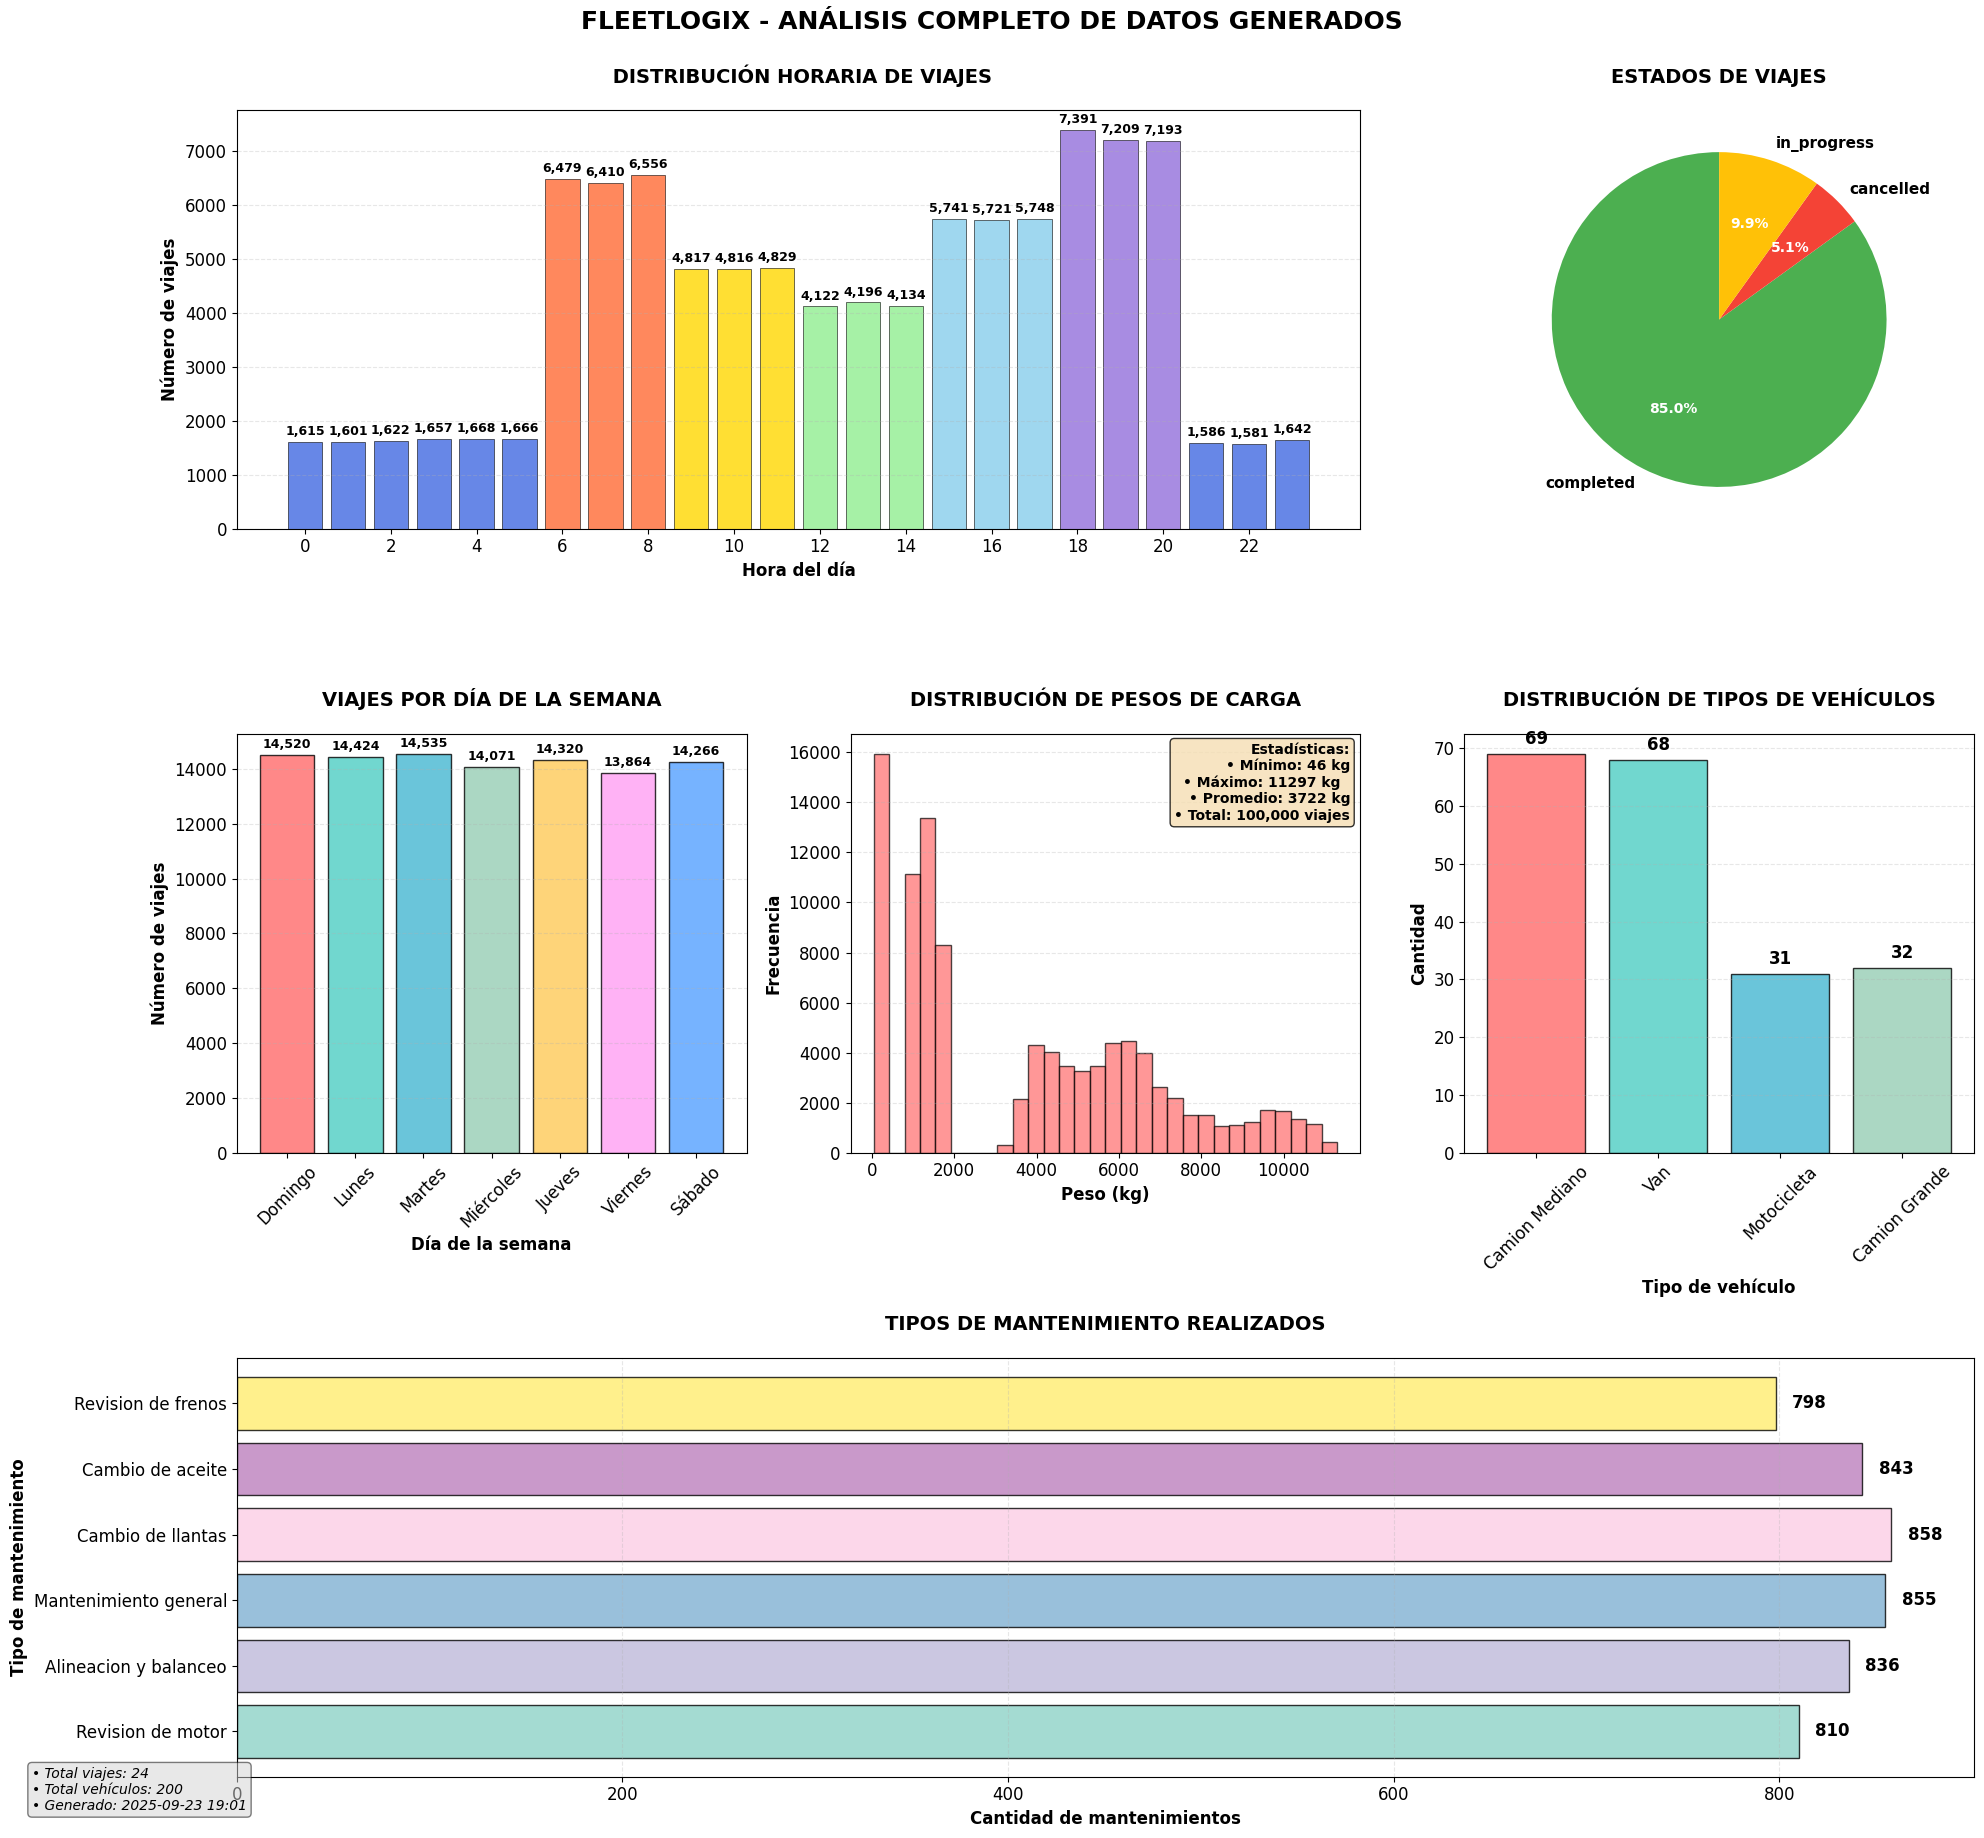

✅ Visualizaciones creadas exitosamente


In [28]:
# Visualización de datos generados con gráficos a color mejorados
def create_enhanced_visualizations():
    """Crea visualizaciones mejoradas de los datos generados"""
    print("CREANDO VISUALIZACIONES MEJORADAS...")
    
    conn = create_db_connection()
    if not conn:
        print("❌ No se pudo conectar a la base de datos para visualizaciones")
        return
    
    try:
        # Obtener datos para visualizaciones
        # 1. Distribución de horas de viaje
        hours_query = """
        SELECT EXTRACT(HOUR FROM departure_datetime) as hour, COUNT(*) as count 
        FROM trips 
        GROUP BY hour ORDER BY hour
        """
        hours_df = pd.read_sql(hours_query, conn)
        
        # 2. Distribución de estados de viajes
        status_query = "SELECT status, COUNT(*) as count FROM trips GROUP BY status"
        status_df = pd.read_sql(status_query, conn)
        
        # 3. Viajes por día de la semana
        days_query = """
        SELECT 
            CASE EXTRACT(DOW FROM departure_datetime)
                WHEN 0 THEN 'Domingo' WHEN 1 THEN 'Lunes' WHEN 2 THEN 'Martes'
                WHEN 3 THEN 'Miércoles' WHEN 4 THEN 'Jueves' WHEN 5 THEN 'Viernes'
                WHEN 6 THEN 'Sábado'
            END as day_name,
            COUNT(*) as count
        FROM trips 
        GROUP BY day_name 
        ORDER BY MIN(EXTRACT(DOW FROM departure_datetime))
        """
        days_df = pd.read_sql(days_query, conn)
        
        # 4. Distribución de pesos de carga
        weights_query = "SELECT total_weight_kg FROM trips WHERE total_weight_kg IS NOT NULL"
        weights_df = pd.read_sql(weights_query, conn)
        
        # 5. Tipos de vehículos
        vehicles_query = "SELECT vehicle_type, COUNT(*) as count FROM vehicles GROUP BY vehicle_type"
        vehicles_df = pd.read_sql(vehicles_query, conn)
        
        # 6. Tipos de mantenimiento
        maintenance_query = "SELECT maintenance_type, COUNT(*) as count FROM maintenance GROUP BY maintenance_type"
        maintenance_df = pd.read_sql(maintenance_query, conn)
        
        # Configurar el estilo de los gráficos
        plt.style.use('default')
        plt.rcParams['figure.figsize'] = [20, 15]
        plt.rcParams['font.size'] = 12
        plt.rcParams['font.family'] = 'DejaVu Sans'
        
        # Crear figura con subplots
        fig = plt.figure(figsize=(20, 18))
        
        # Definir paleta de colores mejorada
        colors_primary = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF9FF3', '#54A0FF']
        colors_pastel = ['#FFB6C1', '#87CEEB', '#98FB98', '#DDA0DD', '#FFD700', '#FFA07A', '#20B2AA']
        
        # 1. GRÁFICO: Distribución horaria de viajes (MEJORADO)
        ax1 = plt.subplot2grid((3, 3), (0, 0), colspan=2)
        hours = hours_df['hour'].astype(int)
        counts = hours_df['count']
        
        # Colores por franja horaria
        hour_colors = []
        for hour in hours:
            if 6 <= hour < 9:    # Mañana - Naranja
                hour_colors.append('#FF6B35')
            elif 9 <= hour < 12: # Media mañana - Amarillo
                hour_colors.append('#FFD700')
            elif 12 <= hour < 15: # Medio día - Verde claro
                hour_colors.append('#90EE90')
            elif 15 <= hour < 18: # Tarde - Azul claro
                hour_colors.append('#87CEEB')
            elif 18 <= hour < 21: # Tarde-noche - Púrpura
                hour_colors.append('#9370DB')
            else:                 # Noche/madrugada - Azul oscuro
                hour_colors.append('#4169E1')
        
        bars = ax1.bar(hours, counts, color=hour_colors, edgecolor='black', linewidth=0.5, alpha=0.8)
        ax1.set_title(' DISTRIBUCIÓN HORARIA DE VIAJES', fontsize=14, fontweight='bold', pad=20)
        ax1.set_xlabel('Hora del día', fontweight='bold', fontsize=12)
        ax1.set_ylabel('Número de viajes', fontweight='bold', fontsize=12)
        ax1.set_xticks(range(0, 24, 2))
        ax1.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Añadir valores en las barras
        for bar, count in zip(bars, counts):
            if count > counts.max() * 0.1:  # Solo mostrar en barras significativas
                ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + counts.max()*0.01, 
                        f'{int(count):,}', ha='center', va='bottom', fontweight='bold', fontsize=9)
        
        # 2. GRÁFICO: Estados de viajes (PIE CHART MEJORADO)
        ax2 = plt.subplot2grid((3, 3), (0, 2))
        status_colors = {'completed': '#4CAF50', 'in_progress': '#FFC107', 'cancelled': '#F44336'}
        pie_colors = [status_colors.get(status, '#999999') for status in status_df['status']]
        
        wedges, texts, autotexts = ax2.pie(
            status_df['count'], 
            labels=status_df['status'], 
            autopct='%1.1f%%', 
            colors=pie_colors, 
            startangle=90,
            textprops={'fontsize': 11, 'fontweight': 'bold'}
        )
        ax2.set_title('ESTADOS DE VIAJES', fontsize=14, fontweight='bold', pad=20)
        
        # Mejorar los textos
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
            autotext.set_fontsize(10)
        
        # 3. GRÁFICO: Viajes por día de la semana
        ax3 = plt.subplot2grid((3, 3), (1, 0))
        day_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF9FF3', '#54A0FF']
        
        bars_days = ax3.bar(days_df['day_name'], days_df['count'], color=day_colors, 
                           edgecolor='black', alpha=0.8)
        ax3.set_title('VIAJES POR DÍA DE LA SEMANA', fontsize=14, fontweight='bold', pad=20)
        ax3.set_xlabel('Día de la semana', fontweight='bold', fontsize=12)
        ax3.set_ylabel('Número de viajes', fontweight='bold', fontsize=12)
        ax3.tick_params(axis='x', rotation=45)
        ax3.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Añadir valores en las barras
        for bar, count in zip(bars_days, days_df['count']):
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + days_df['count'].max()*0.01, 
                    f'{int(count):,}', ha='center', va='bottom', fontweight='bold', fontsize=9)
        
        # 4. GRÁFICO: Distribución de pesos de carga
        ax4 = plt.subplot2grid((3, 3), (1, 1))
        weights = weights_df['total_weight_kg']
        n_bins = 30
        
        n, bins, patches = ax4.hist(weights, bins=n_bins, edgecolor='black', alpha=0.7, 
                                   color='#FF6B6B')
        ax4.set_title('DISTRIBUCIÓN DE PESOS DE CARGA', fontsize=14, fontweight='bold', pad=20)
        ax4.set_xlabel('Peso (kg)', fontweight='bold', fontsize=12)
        ax4.set_ylabel('Frecuencia', fontweight='bold', fontsize=12)
        ax4.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Añadir estadísticas
        stats_text = f'''Estadísticas:
• Mínimo: {weights.min():.0f} kg
• Máximo: {weights.max():.0f} kg  
• Promedio: {weights.mean():.0f} kg
• Total: {len(weights):,} viajes'''
        
        ax4.text(0.98, 0.98, stats_text, transform=ax4.transAxes, 
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
                fontsize=10, fontweight='bold')
        
        # 5. GRÁFICO: Tipos de vehículos
        ax5 = plt.subplot2grid((3, 3), (1, 2))
        vehicle_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
        
        bars_vehicles = ax5.bar(vehicles_df['vehicle_type'], vehicles_df['count'], 
                               color=vehicle_colors, edgecolor='black', alpha=0.8)
        ax5.set_title('DISTRIBUCIÓN DE TIPOS DE VEHÍCULOS', fontsize=14, fontweight='bold', pad=20)
        ax5.set_xlabel('Tipo de vehículo', fontweight='bold', fontsize=12)
        ax5.set_ylabel('Cantidad', fontweight='bold', fontsize=12)
        ax5.tick_params(axis='x', rotation=45)
        ax5.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Añadir valores en las barras
        for bar, count in zip(bars_vehicles, vehicles_df['count']):
            ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                    f'{int(count)}', ha='center', va='bottom', fontweight='bold')
        
        # 6. GRÁFICO: Tipos de mantenimiento
        ax6 = plt.subplot2grid((3, 3), (2, 0), colspan=3)
        maintenance_colors = plt.cm.Set3(np.linspace(0, 1, len(maintenance_df)))
        
        bars_maintenance = ax6.barh(maintenance_df['maintenance_type'], maintenance_df['count'], 
                                   color=maintenance_colors, edgecolor='black', alpha=0.8)
        ax6.set_title('TIPOS DE MANTENIMIENTO REALIZADOS', fontsize=14, fontweight='bold', pad=20)
        ax6.set_xlabel('Cantidad de mantenimientos', fontweight='bold', fontsize=12)
        ax6.set_ylabel('Tipo de mantenimiento', fontweight='bold', fontsize=12)
        ax6.grid(axis='x', alpha=0.3, linestyle='--')
        
        # Añadir valores en las barras
        for bar, count in zip(bars_maintenance, maintenance_df['count']):
            ax6.text(bar.get_width() + max(maintenance_df['count'])*0.01, bar.get_y() + bar.get_height()/2, 
                    f'{int(count)}', ha='left', va='center', fontweight='bold')
        
        # Ajustar layout
        plt.tight_layout()
        plt.suptitle('FLEETLOGIX - ANÁLISIS COMPLETO DE DATOS GENERADOS', 
                    fontsize=18, fontweight='bold', y=1.02)
        
        # Añadir texto informativo
        fig.text(0.02, 0.02, 
                f'• Total viajes: {len(hours_df):,}\n• Total vehículos: {vehicles_df["count"].sum():,}\n• Generado: {datetime.now().strftime("%Y-%m-%d %H:%M")}',
                fontsize=10, style='italic', bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))
        
        plt.show()
        
        print("✅ Visualizaciones creadas exitosamente")
        
    except Exception as e:
        print(f"❌ Error creando visualizaciones: {e}")
        import traceback
        traceback.print_exc()
    finally:
        if conn:
            conn.close()

# Crear visualizaciones mejoradas
create_enhanced_visualizations()

### Para cerrar, un analisis de tendencias temporales
- Crear gráficos de evolución mensual de viajes
- Mostrar tasas de viajes completos a lo largo del tiempo
- Identificar patrones estacionales y de crecimiento

2025-09-23 19:02:29,593 - INFO - Conexión a la base de datos establecida exitosamente



 CREANDO GRÁFICO DE EVOLUCIÓN TEMPORAL...


C:\Users\yaela\AppData\Local\Temp\ipykernel_12596\1421110894.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthly_df = pd.read_sql(monthly_query, conn)
C:\Users\yaela\AppData\Local\Temp\ipykernel_12596\1421110894.py:64: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yaela\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


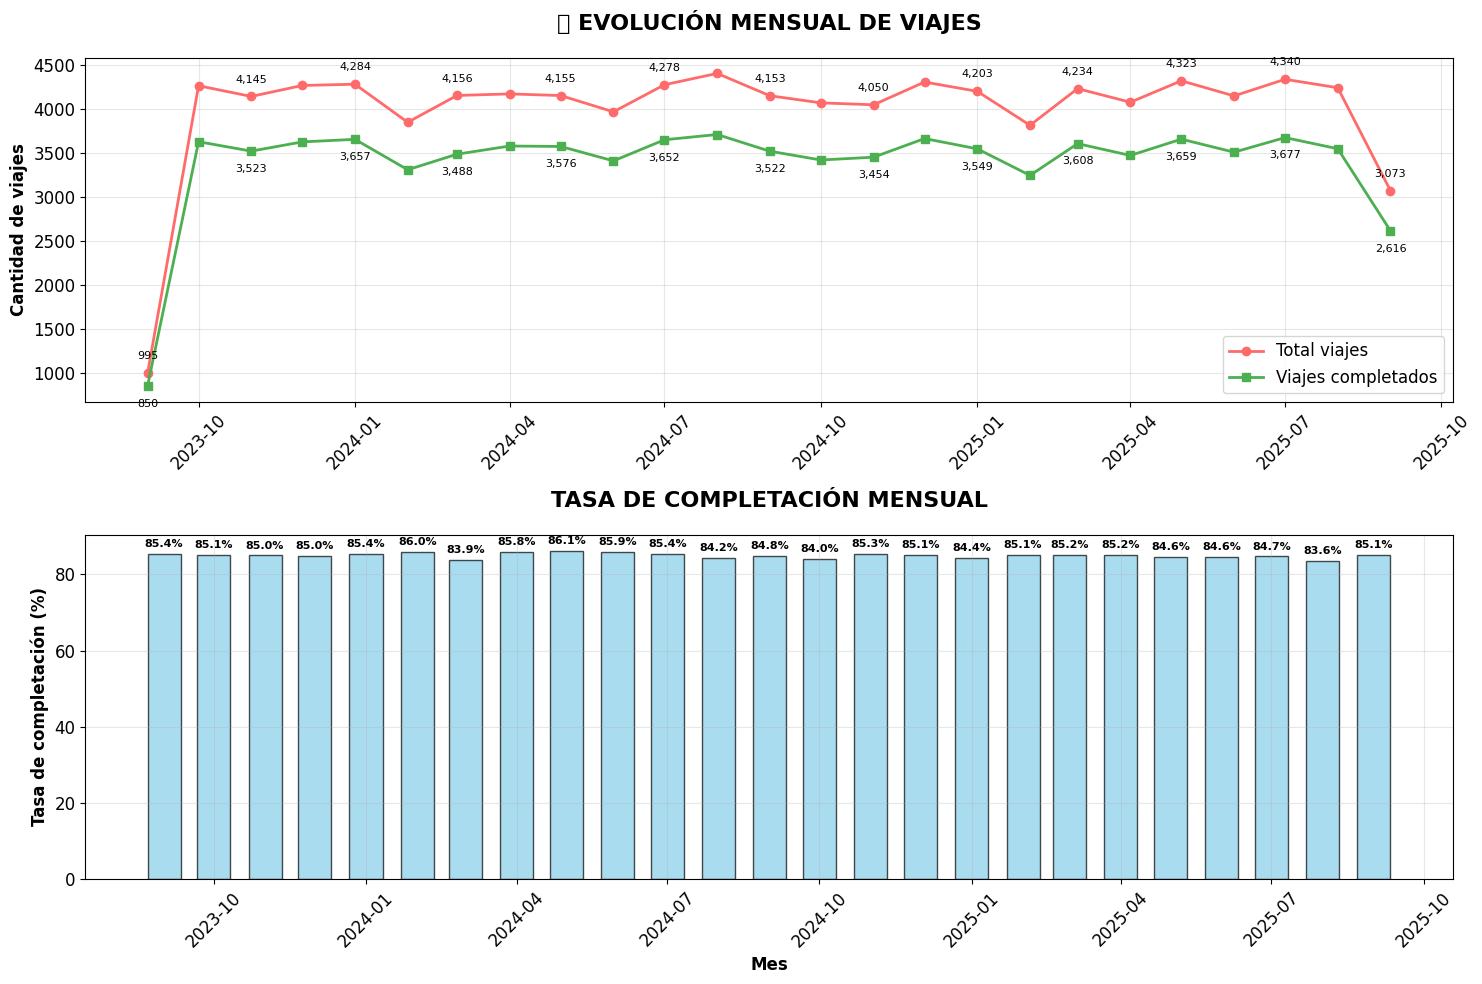

📊 Estadísticas temporales:
   • Período cubierto: Sep 2023 - Sep 2025
   • Mes con más viajes: Aug 2024 (4,407 viajes)
   • Tasa de completación promedio: 85.0%

 ¡TODAS LAS VISUALIZACIONES COMPLETADAS!
   Los gráficos muestran el análisis completo de los datos generados.


In [29]:
# Gráfico adicional: Evolución temporal de viajes
def create_temporal_evolution_chart():
    """Crea gráfico de evolución temporal de viajes"""
    print("\n CREANDO GRÁFICO DE EVOLUCIÓN TEMPORAL...")
    
    conn = create_db_connection()
    if not conn:
        print("❌ No se pudo conectar a la base de datos")
        return
    
    try:
        # Obtener datos mensuales de viajes
        monthly_query = """
        SELECT 
            DATE_TRUNC('month', departure_datetime) as month,
            COUNT(*) as trip_count,
            COUNT(CASE WHEN status = 'completed' THEN 1 END) as completed_trips
        FROM trips 
        GROUP BY month 
        ORDER BY month
        """
        monthly_df = pd.read_sql(monthly_query, conn)
        monthly_df['month'] = pd.to_datetime(monthly_df['month'])
        monthly_df['completion_rate'] = (monthly_df['completed_trips'] / monthly_df['trip_count']) * 100
        
        # Crear gráfico
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
        
        # Gráfico 1: Cantidad de viajes por mes
        ax1.plot(monthly_df['month'], monthly_df['trip_count'], 
                marker='o', linewidth=2, markersize=6, color='#FF6B6B', label='Total viajes')
        ax1.plot(monthly_df['month'], monthly_df['completed_trips'], 
                marker='s', linewidth=2, markersize=6, color='#4CAF50', label='Viajes completados')
        ax1.set_title('📈 EVOLUCIÓN MENSUAL DE VIAJES', fontsize=16, fontweight='bold', pad=20)
        ax1.set_ylabel('Cantidad de viajes', fontweight='bold', fontsize=12)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax1.tick_params(axis='x', rotation=45)
        
        # Añadir valores en los puntos
        for i, (month, count, completed) in enumerate(zip(monthly_df['month'], 
                                                         monthly_df['trip_count'], 
                                                         monthly_df['completed_trips'])):
            if i % 2 == 0:  # Mostrar cada dos meses para evitar saturación
                ax1.annotate(f'{int(count):,}', (month, count), 
                           textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)
                ax1.annotate(f'{int(completed):,}', (month, completed), 
                           textcoords="offset points", xytext=(0,-15), ha='center', fontsize=8)
        
        # Gráfico 2: Tasa de completación
        ax2.bar(monthly_df['month'], monthly_df['completion_rate'], 
               color='#87CEEB', alpha=0.7, edgecolor='black', width=20)
        ax2.set_title('TASA DE COMPLETACIÓN MENSUAL', fontsize=16, fontweight='bold', pad=20)
        ax2.set_xlabel('Mes', fontweight='bold', fontsize=12)
        ax2.set_ylabel('Tasa de completación (%)', fontweight='bold', fontsize=12)
        ax2.grid(True, alpha=0.3)
        ax2.tick_params(axis='x', rotation=45)
        
        # Añadir valores en las barras
        for month, rate in zip(monthly_df['month'], monthly_df['completion_rate']):
            ax2.annotate(f'{rate:.1f}%', (month, rate), 
                       textcoords="offset points", xytext=(0,5), ha='center', fontsize=8, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        # Estadísticas del gráfico
        print(f"📊 Estadísticas temporales:")
        print(f"   • Período cubierto: {monthly_df['month'].min().strftime('%b %Y')} - {monthly_df['month'].max().strftime('%b %Y')}")
        print(f"   • Mes con más viajes: {monthly_df.loc[monthly_df['trip_count'].idxmax(), 'month'].strftime('%b %Y')} ({monthly_df['trip_count'].max():,} viajes)")
        print(f"   • Tasa de completación promedio: {monthly_df['completion_rate'].mean():.1f}%")
        
    except Exception as e:
        print(f"❌ Error creando gráfico temporal: {e}")
    finally:
        if conn:
            conn.close()

# Crear gráfico temporal
create_temporal_evolution_chart()

print("\n ¡TODAS LAS VISUALIZACIONES COMPLETADAS!")
print("   Los gráficos muestran el análisis completo de los datos generados.")

### Listo para comenzar el Avance 2


# 🔧 Post-procesado de Calidad de Datos (FleetLogix)
# Tras correr la pipeline notamos una falta consistente de datos, por lo que sumo estos bloques de codigo

Este bloque NO reemplaza la generación original. Suma un *post-procesado* que:
- Completa `delivered_datetime` faltantes con una distribución realista.
- Garantiza consistencia temporal: `arrival_datetime > departure_datetime` y `delivered_datetime >= scheduled_datetime`.
- Completa `recipient_signature` (más probable cuando hay entrega).
- Ajusta `delivery_status` a `'delivered'` cuando corresponde.
- Estima `fuel_consumed_liters` faltante en `trips` según `vehicle_type` y `distance_km`.
- Deja **logs** y un **resumen** de calidad para documentar en el TP.


In [1]:
# 1) Config y conexión (SQLAlchemy)
import pandas as pd
from sqlalchemy import create_engine, text

pg_config = {
    'host': 'localhost',
    'database': 'fleetlogix',
    'user': 'fleetlogix_user',
    'password': 'fleetlogix123',
    'port': '5432'
}

dsn = f"postgresql+psycopg2://{pg_config['user']}:{pg_config['password']}@{pg_config['host']}:{pg_config['port']}/{pg_config['database']}"
engine = create_engine(dsn, pool_pre_ping=True)

with engine.connect() as con:
    con.execute(text("SELECT 1"))
print("✅ Conexión PostgreSQL OK")


✅ Conexión PostgreSQL OK


In [9]:
from sqlalchemy import text

def run_update(con, sql, **params):
    res = con.execute(text(sql), params)
    try:
        affected = res.rowcount
    except Exception:
        affected = None
    return affected

with engine.begin() as con:  # begin = abre transacción automática (commit/rollback)
    print("🛠️ Iniciando post-procesado de calidad…")

    # A) Trips: asegurar arrival > departure con ruido realista basado en la ruta
    #   - Si estimated_duration_hours no está, usamos distancia/35 km/h como backup.
    sql_arrival = """
    UPDATE trips t
    SET arrival_datetime =
        t.departure_datetime
        + (INTERVAL '1 minute' * GREATEST(
              20,  -- mínimo 20 minutos
              ROUND( (COALESCE(r.estimated_duration_hours, r.distance_km/35.0) * 60.0)
                     * (0.85 + (random()*0.30))  -- ruido -15% a +15%
              )
          ))
    FROM routes r
    WHERE r.route_id = t.route_id
      AND (t.arrival_datetime IS NULL OR t.arrival_datetime <= t.departure_datetime);
    """
    a1 = run_update(con, sql_arrival)
    print(f"✔️ Trips (arrival fix): {a1} filas ajustadas")

    # B) Deliveries: completar delivered_datetime NULL con distribución más realista
    #   - 15% antes de hora (hasta 10 min), 65% on-time (0 a +20 min),
    #     20% tarde (+20 a +120 min).
    sql_delivered = """
    WITH base AS (
      SELECT d.delivery_id,
             d.scheduled_datetime,
             CASE
               WHEN rnd < 0.15 THEN d.scheduled_datetime - (INTERVAL '1 minute' * FLOOR(random()*10))            -- hasta 10 min antes
               WHEN rnd < 0.80 THEN d.scheduled_datetime + (INTERVAL '1 minute' * FLOOR(random()*21))           -- 0 a 20 min después
               ELSE                        d.scheduled_datetime + (INTERVAL '1 minute' * (20 + FLOOR(random()*101))) -- 20 a 120 min tarde
             END AS new_delivered
      FROM (
        SELECT delivery_id, scheduled_datetime, random() AS rnd
        FROM deliveries
        WHERE delivered_datetime IS NULL
              AND scheduled_datetime IS NOT NULL
      ) d
    )
    UPDATE deliveries dd
    SET delivered_datetime = b.new_delivered
    FROM base b
    WHERE b.delivery_id = dd.delivery_id;
    """
    a2 = run_update(con, sql_delivered)
    print(f"✔️ Deliveries (completar delivered): {a2} filas actualizadas")

    # C) Deliveries: asegurar delivered >= scheduled (por si quedaron negativos)
    sql_delivered_floor = """
    UPDATE deliveries
    SET delivered_datetime = GREATEST(delivered_datetime, scheduled_datetime)
    WHERE delivered_datetime IS NOT NULL
      AND scheduled_datetime IS NOT NULL
      AND delivered_datetime < scheduled_datetime;
    """
    a3 = run_update(con, sql_delivered_floor)
    print(f"✔️ Deliveries (floor delivered>=scheduled): {a3} filas corregidas")

    # D) Recipient signature: true con prob 0.85 cuando hay delivered, false si no
    sql_signature = """
    UPDATE deliveries
    SET recipient_signature = CASE
        WHEN delivered_datetime IS NOT NULL THEN (random() < 0.85)
        ELSE FALSE
      END
    WHERE recipient_signature IS NULL
       OR delivered_datetime IS NULL;  -- asegura false si no hay entrega
    """
    a4 = run_update(con, sql_signature)
    print(f"✔️ Deliveries (signature): {a4} filas actualizadas")

    # E) Delivery status: 'delivered' cuando delivered_datetime no es NULL
    sql_status = """
    UPDATE deliveries
    SET delivery_status = CASE
        WHEN delivered_datetime IS NOT NULL THEN 'delivered'
        ELSE COALESCE(delivery_status, 'pending')
      END
    WHERE delivery_status IS DISTINCT FROM
          CASE WHEN delivered_datetime IS NOT NULL THEN 'delivered'
               ELSE COALESCE(delivery_status, 'pending') END;
    """
    a5 = run_update(con, sql_status)
    print(f"✔️ Deliveries (status): {a5} filas ajustadas")

# F) Trips: fuel_consumed_liters faltante estimado por tipo de vehículo y distancia
#   Eficiencias base (km/l): Moto 30, Van 8, Camión Med 4.5, Camión Grande 3.5
sql_fuel = """
UPDATE trips t
SET fuel_consumed_liters = sub.fuel_est
FROM (
    SELECT t2.trip_id,
           ROUND(
             (r.distance_km / CASE
                 WHEN LOWER(v.vehicle_type) LIKE '%moto%' THEN 30.0
                 WHEN LOWER(v.vehicle_type) LIKE '%van%'  THEN 8.0
                 WHEN LOWER(v.vehicle_type) LIKE '%med%'  THEN 4.5
                 WHEN LOWER(v.vehicle_type) LIKE '%gran%' THEN 3.5
                 ELSE 6.0
             END)
             * (0.9 + (random()*0.2))::numeric, 2
           ) AS fuel_est
      FROM trips t2
      JOIN vehicles v ON v.vehicle_id = t2.vehicle_id
      JOIN routes r   ON r.route_id   = t2.route_id
     WHERE (t2.fuel_consumed_liters IS NULL OR t2.fuel_consumed_liters <= 0)
       AND r.distance_km IS NOT NULL
) AS sub
WHERE sub.trip_id = t.trip_id;
"""

with engine.begin() as con:
    print("🔁 Recalculando fuel_consumed_liters faltante (modo subquery)…")
    a6 = run_update(con, sql_fuel)
    print(f"✔️ Trips (fuel estimado): {a6} filas completadas")

print("✅ Post-procesado finalizado.")


🛠️ Iniciando post-procesado de calidad…
✔️ Trips (arrival fix): 0 filas ajustadas
✔️ Deliveries (completar delivered): 0 filas actualizadas
✔️ Deliveries (floor delivered>=scheduled): 0 filas corregidas
✔️ Deliveries (signature): 0 filas actualizadas
✔️ Deliveries (status): 0 filas ajustadas
🔁 Recalculando fuel_consumed_liters faltante (modo subquery)…
✔️ Trips (fuel estimado): 15025 filas completadas
✅ Post-procesado finalizado.


## ✅ Verificación de calidad y operación (para el informe)

En esta sección generamos gráficos “listos para captura” y tablas resumidas:
- **Evolución mensual de viajes** (totales vs completados) y **tasa de completación**.
- **Distribución horaria**, **por día de semana** y **estados** de viajes.
- **Distribución de peso** de carga.
- **Mix de vehículos** y **tipos de mantenimiento**.
- **Resumen de ejecución** (registros, velocidad, etc.).

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import ScalarFormatter
from sqlalchemy import text

def _q(sql):
    with engine.connect() as con:
        return pd.read_sql(text(sql), con)

def format_axis(ax, numeric_axis='y', rotation=0):
    """Grilla y desactivar notación científica solo en el eje numérico."""
    ax.grid(alpha=.25, linestyle='--', axis='both')
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(rotation)
    try:
        if numeric_axis == 'y':
            if isinstance(ax.yaxis.get_major_formatter(), ScalarFormatter):
                ax.ticklabel_format(axis='y', style='plain')
        elif numeric_axis == 'x':
            if isinstance(ax.xaxis.get_major_formatter(), ScalarFormatter):
                ax.ticklabel_format(axis='x', style='plain')
    except Exception:
        pass  # si el eje es categórico, no formateamos

def thin_xtick_labels(ax, keep_every=2):
    """Muestra solo 1 de cada N etiquetas del eje X para evitar amontonamiento."""
    ticks = ax.get_xticks()
    labels = ax.get_xticklabels()
    for i, lab in enumerate(labels):
        lab.set_visible(i % keep_every == 0)


Creando gráfico: evolución temporal de viajes…


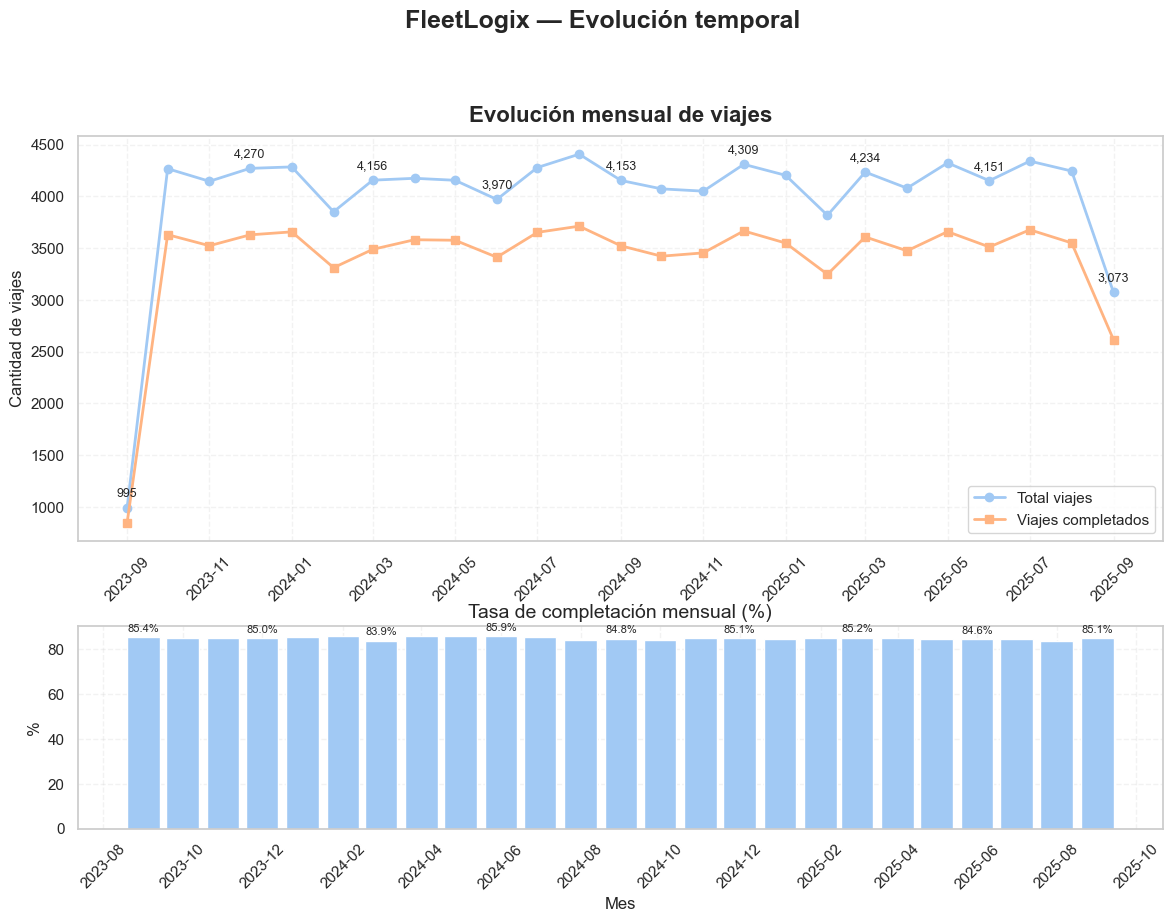

Estadísticas:
 • Período: sept 2023 – sept 2025
 • Mes con más viajes: ago 2024 (4,407)
 • Tasa promedio: 85.0%


In [23]:
def create_temporal_evolution_chart():
    """Evolución mensual de viajes (totales vs completados) y tasa de completación."""
    print("Creando gráfico: evolución temporal de viajes…")
    monthly = _q("""
        SELECT DATE_TRUNC('month', departure_datetime) AS month,
               COUNT(*) AS trip_count,
               COUNT(*) FILTER (WHERE status='completed') AS completed_trips
        FROM trips
        GROUP BY 1
        ORDER BY 1
    """)
    if monthly.empty:
        print("No hay datos para graficar.")
        return
    
    monthly["month"] = pd.to_datetime(monthly["month"])
    monthly["completion_rate"] = monthly["completed_trips"] / monthly["trip_count"] * 100

    fig = plt.figure(figsize=(14,9))
    gs = fig.add_gridspec(2,1, height_ratios=[2,1], hspace=0.28)
    ax1 = fig.add_subplot(gs[0,0])
    ax2 = fig.add_subplot(gs[1,0])

    # Serie: totales y completados
    ax1.plot(monthly["month"], monthly["trip_count"], marker='o', linewidth=2, label='Total viajes')
    ax1.plot(monthly["month"], monthly["completed_trips"], marker='s', linewidth=2, label='Viajes completados')
    ax1.set_title("Evolución mensual de viajes", fontsize=16, fontweight='bold', pad=10)
    ax1.set_ylabel("Cantidad de viajes")
    ax1.legend()

    # Eje X con meses: mostrar 1 de cada 2 etiquetas
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    format_axis(ax1, 'y', rotation=45)

    # Serie: tasa de completación
    ax2.bar(monthly["month"], monthly["completion_rate"], width=25)
    ax2.set_title("Tasa de completación mensual (%)", fontsize=14, pad=6)
    ax2.set_xlabel("Mes")
    ax2.set_ylabel("%")
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    format_axis(ax2, 'y', rotation=45)

    # Anotaciones espaciadas
    for i, (x, y) in enumerate(zip(monthly["month"], monthly["trip_count"])):
        if i % 3 == 0:
            ax1.annotate(f"{int(y):,}", (x, y), xytext=(0,8), textcoords="offset points", ha='center', fontsize=9)
    for i, (x, y) in enumerate(zip(monthly["month"], monthly["completion_rate"])):
        if i % 3 == 0:
            ax2.annotate(f"{y:.1f}%", (x, y), xytext=(0,4), textcoords="offset points", ha='center', fontsize=8)

    fig.suptitle("FleetLogix — Evolución temporal", fontsize=18, fontweight='bold', y=1.02)
    plt.show()

    print("Estadísticas:")
    print(f" • Período: {monthly['month'].min():%b %Y} – {monthly['month'].max():%b %Y}")
    print(f" • Mes con más viajes: {monthly.loc[monthly['trip_count'].idxmax(), 'month']:%b %Y} "
          f"({monthly['trip_count'].max():,})")
    print(f" • Tasa promedio: {monthly['completion_rate'].mean():.1f}%")

create_temporal_evolution_chart()


Creando dashboard de visualizaciones…


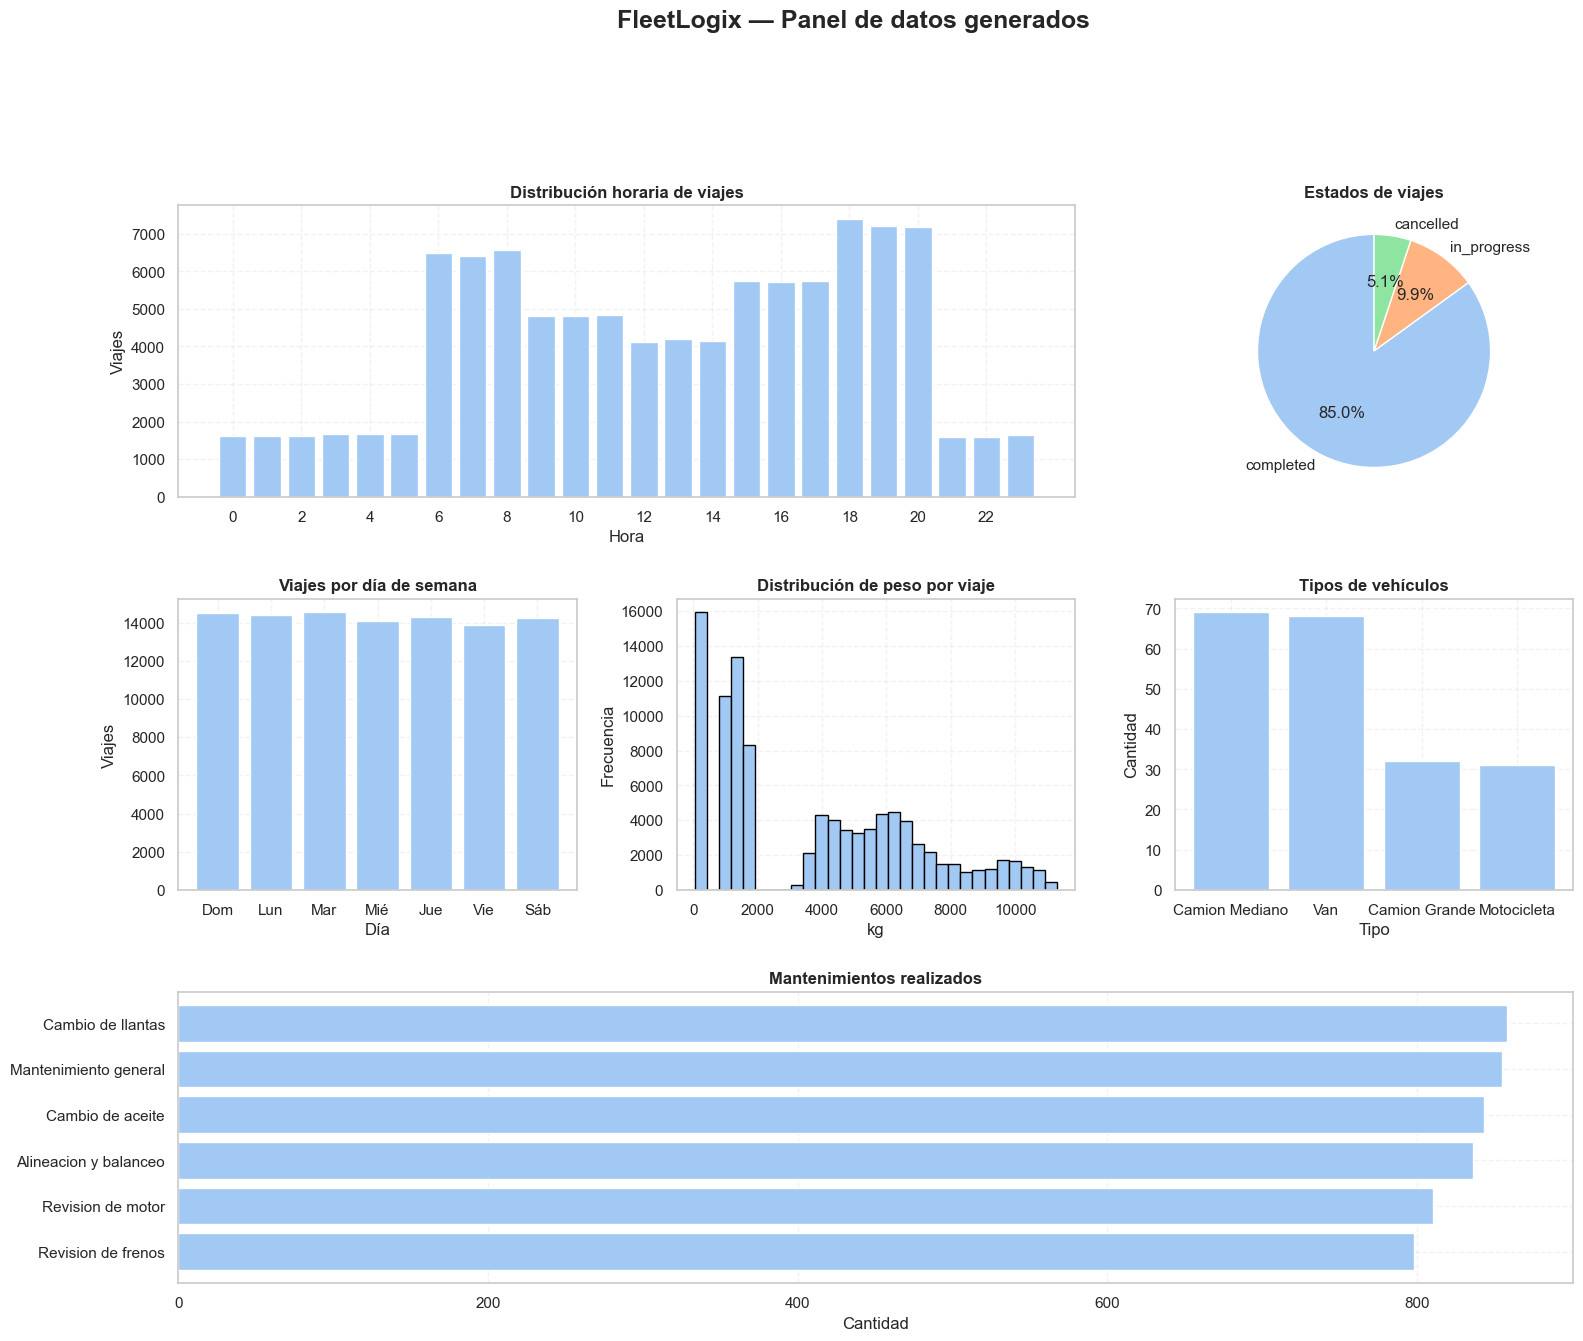

In [25]:
def create_enhanced_visualizations():
    """Dashboard: horas, estado, día, peso, vehículos, mantenimiento."""
    print("Creando dashboard de visualizaciones…")
    hours   = _q("SELECT EXTRACT(HOUR FROM departure_datetime)::int AS hour, COUNT(*) AS count FROM trips GROUP BY 1 ORDER BY 1")
    status  = _q("SELECT status, COUNT(*) AS count FROM trips GROUP BY 1 ORDER BY 2 DESC")
    dow     = _q("""
        SELECT CASE EXTRACT(DOW FROM departure_datetime)
                 WHEN 0 THEN 'Dom' WHEN 1 THEN 'Lun' WHEN 2 THEN 'Mar'
                 WHEN 3 THEN 'Mié' WHEN 4 THEN 'Jue' WHEN 5 THEN 'Vie' WHEN 6 THEN 'Sáb' END AS dia,
               COUNT(*) AS count,
               MIN(EXTRACT(DOW FROM departure_datetime)) AS ord
        FROM trips GROUP BY 1 ORDER BY 3
    """)
    weights = _q("SELECT total_weight_kg FROM trips WHERE total_weight_kg IS NOT NULL")
    vehicles= _q("SELECT vehicle_type, COUNT(*) AS count FROM vehicles GROUP BY 1 ORDER BY 2 DESC")
    maint   = _q("SELECT maintenance_type, COUNT(*) AS count FROM maintenance GROUP BY 1 ORDER BY 2 DESC")

    fig = plt.figure(figsize=(18,14))
    gs  = fig.add_gridspec(3,3, hspace=0.35, wspace=0.25)

    ax1 = fig.add_subplot(gs[0,0:2])
    ax2 = fig.add_subplot(gs[0,2])
    ax3 = fig.add_subplot(gs[1,0])
    ax4 = fig.add_subplot(gs[1,1])
    ax5 = fig.add_subplot(gs[1,2])
    ax6 = fig.add_subplot(gs[2,0:3])

    # 1) Distribución horaria
    ax1.bar(hours["hour"], hours["count"])
    ax1.set_title("Distribución horaria de viajes", fontweight='bold')
    ax1.set_xlabel("Hora")
    ax1.set_ylabel("Viajes")
    ax1.set_xticks(range(0,24,2))
    format_axis(ax1, 'y')

    # 2) Estados (pie)
    if not status.empty:
        ax2.pie(status["count"], labels=status["status"], autopct='%1.1f%%', startangle=90)
    ax2.set_title("Estados de viajes", fontweight='bold')

    # 3) Día de semana
    ax3.bar(dow["dia"], dow["count"])
    ax3.set_title("Viajes por día de semana", fontweight='bold')
    ax3.set_xlabel("Día")
    ax3.set_ylabel("Viajes")
    format_axis(ax3, 'y')

    # 4) Peso (histograma)
    ax4.hist(weights["total_weight_kg"], bins=30, edgecolor='black')
    ax4.set_title("Distribución de peso por viaje", fontweight='bold')
    ax4.set_xlabel("kg")
    ax4.set_ylabel("Frecuencia")
    format_axis(ax4, 'y')

    # 5) Tipos de vehículos
    ax5.bar(vehicles["vehicle_type"], vehicles["count"])
    ax5.set_title("Tipos de vehículos", fontweight='bold')
    ax5.set_xlabel("Tipo")
    ax5.set_ylabel("Cantidad")
    for t in ax5.get_xticklabels(): t.set_rotation(20)
    format_axis(ax5, 'y')

    # 6) Mantenimiento (horizontal)
    ax6.barh(maint["maintenance_type"], maint["count"])
    ax6.set_title("Mantenimientos realizados", fontweight='bold')
    ax6.set_xlabel("Cantidad")
    ax6.invert_yaxis()
    format_axis(ax6, 'x')   # en barh el eje numérico es X

    fig.suptitle("FleetLogix — Panel de datos generados", fontsize=18, fontweight='bold', y=1.02)
    plt.show()

create_enhanced_visualizations()


In [26]:
def show_summary_metrics():
    """Muestra métricas clave: viajes, entregas, puntualidad, consumo, mantenimiento."""
    print("\n" + "="*70)
    print("RESUMEN DE MÉTRICAS CLAVE")
    print("="*70)

    # 1. Viajes totales y promedio por vehículo
    trips_stats = _q("""
        SELECT COUNT(*) AS total_trips,
               ROUND(AVG(fuel_consumed_liters),2) AS avg_fuel,
               ROUND(AVG(total_weight_kg),2) AS avg_weight
        FROM trips;
    """)
    print(f"Viajes totales: {int(trips_stats.loc[0,'total_trips']):,}")
    print(f"Consumo promedio por viaje: {trips_stats.loc[0,'avg_fuel']} litros")
    print(f"Peso promedio por viaje: {trips_stats.loc[0,'avg_weight']} kg")

    # 2. Entregas y puntualidad
    punctuality = _q("""
        SELECT
          COUNT(*) AS total_deliveries,
          COUNT(*) FILTER (WHERE delivered_datetime <= scheduled_datetime) AS on_time,
          COUNT(*) FILTER (WHERE delivered_datetime > scheduled_datetime) AS late,
          ROUND(100.0 * COUNT(*) FILTER (WHERE delivered_datetime <= scheduled_datetime) / COUNT(*), 2) AS pct_on_time
        FROM deliveries;
    """)
    print("\nEntregas totales:", int(punctuality.loc[0,'total_deliveries']))
    print(f"Entregas a tiempo: {int(punctuality.loc[0,'on_time']):,}  ({punctuality.loc[0,'pct_on_time']}%)")
    print(f"Entregas con demora: {int(punctuality.loc[0,'late']):,}")

    # 3. Mantenimiento: frecuencia y costo promedio
    maint_stats = _q("""
        SELECT COUNT(*) AS total_maint,
               ROUND(AVG(cost),2) AS avg_cost,
               ROUND(SUM(cost),2) AS total_cost
        FROM maintenance;
    """)
    print("\nMantenimientos registrados:", int(maint_stats.loc[0,'total_maint']))
    print(f"Costo promedio: ${maint_stats.loc[0,'avg_cost']:,}")
    print(f"Costo total estimado: ${maint_stats.loc[0,'total_cost']:,}")

    # 4. Vehículos activos por tipo
    veh_stats = _q("""
        SELECT vehicle_type, COUNT(*) AS count
        FROM vehicles
        WHERE status='active'
        GROUP BY 1 ORDER BY 2 DESC;
    """)
    print("\nVehículos activos por tipo:")
    for _, row in veh_stats.iterrows():
        print(f"  - {row['vehicle_type']}: {int(row['count']):,}")

    # 5. Promedio de entregas por viaje
    ratio = _q("""
        SELECT ROUND(COUNT(*)::numeric / (SELECT COUNT(*) FROM trips), 2) AS deliveries_per_trip
        FROM deliveries;
    """)
    print(f"\nPromedio de entregas por viaje: {ratio.loc[0,'deliveries_per_trip']}")

    print("="*70)
    print("Fin del resumen de métricas.\n")

show_summary_metrics()



RESUMEN DE MÉTRICAS CLAVE
Viajes totales: 100,000
Consumo promedio por viaje: 90.91 litros
Peso promedio por viaje: 3721.58 kg

Entregas totales: 400000
Entregas a tiempo: 366,012  (91.5%)
Entregas con demora: 33,988

Mantenimientos registrados: 5000
Costo promedio: $1,979.85
Costo total estimado: $9,899,251.03

Vehículos activos por tipo:
  - Camion Mediano: 59
  - Van: 53
  - Motocicleta: 26
  - Camion Grande: 24

Promedio de entregas por viaje: 4.0
Fin del resumen de métricas.

